# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.2  Продвинутая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с менее тривиальными подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

См. базовую часть

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-advanced-Username.ipynb**, где Username — ваша фамилия.

### **Введение**

В этой части ноутбука задания посложнее дефолтного фит трансформа. Максимальная оценка за оба — 8 баллов, остальное вы можете получить, если примете участие в соревновании, и всего можете выбить аж 13 из 10. Тут ожидается больше самостоятельности, как от (почти) полноценной рабочей единицы: 
- Вы **сами** решаете, что <font color="#cb9255">**хотите**</font> делать. Пункты можно делать частично, можно скипать или сделать часть, **максимум баллов ограничен двумя**. **Посмотрите на все из них**, прежде чем приступать
- Вы **сами** чистите данные, если чуете в них подвох (теперь они далеко не такие няшные)
- Вы **сами** <font color="#f68c9d">**обосновываете**</font> (в голове, если не указано явно), могут они вам вообще помочь или нет (часть пунктов явно сильнее других)

Все прочие пожелания по тому, как строить графики, на чём фиттить, а на чём предиктить, сохраняются, будьте внимательны. Во всех пунктах с 📈 нужно добиться хотя бы минимального улучшения, относительно бейзлайна (того, что вышло в части **base**) чтобы получить балл (даже если улучшение на 0.005)

Ещё раз обратите внимание, что **максимум за advanced часть — 2 балла**, делать всё не нужно, только самое приятное. Мы в вас верим!

In [1]:
from IPython.core.usage import default_banner
from joblib import Memory
from pathlib import Path

from scipy.stats import alpha
from sklearn.preprocessing import StandardScaler

artifacts_cache_dir = Path('data/artifacts/cache/')
artifacts_cache_dir.mkdir(exist_ok=True, parents=True)
artifacts_memory = Memory(artifacts_cache_dir, verbose=0)

In [2]:
from experiment_storage import ExperimentStorage
storage = ExperimentStorage()

/Users/ppers/hse_work/machine_learning/hw3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Часть 4. Текста** (1.5 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4f/Emoticon_blush.gif/revision/latest?cb=20180504011409">

В которой студент знакомится с внутренним миром дотеров

#### **Задание 4.1. Предобработка текста** (0.75 балла)

<span style="color:grey"><font size="1">Если вам когда-либо приходила в голову мысль, что создание Интернета было ошибкой, то, что ж, после этого задания сомнения могут отпасть.</font></span>

Для некоторых матчей имеется информация о том, что писали местные аборигены, в течение тех же **15 минут от начала матча**. К сожалению, доселе мы работали лишь с таблицами, а не с текстами, но не беда, простейшие подходы нейросетей не требуют, а в простых задачах, вроде бинарной классификации, работать будут не хуже

Откройте датафрейм `game_chat.csv`, выведите парочку текстов, посмотрите, как они устроены, как там хранятся множественные сообщения,  и так далее, что у нас есть, а чего, увы, нет

In [3]:
import polars as pl
from scipy.sparse import csr_matrix, hstack

chat_raw_df = pl.read_csv('data/game_chat.csv')
chat_raw_df.head(5)

match_id,radiant_chat,dire_chat
i64,str,str
235435,"""потренируйся с ботами????""","""саппортам | U LAGGING BRAH | s…"
102127,null,null
383046,"""u just buy levels blue? | fa g…",null
729879,null,null
126886,null,null


In [4]:
chat_raw_df['match_id'].value_counts().sort(by='count', descending=True).head(3)

match_id,count
i64,u32
243442,1
210364,1
31899,1


Дём дальше. Тексты нужно готовить, прежде чем пихать их в модель. Оценивать выбросы здесь довольно проблематично, в силу специфики дотерских сообщений, хотя вы, конечно, можете попытаться. Речь здесь про базовую предобработку.

Задача минимум, тут мы вам поможем:
- Разобраться с библиотекой `nltk` и разбить текст на токены — отдельные сущности, составляющие текст (чаще всего слова, но бывает и что-то другое, надо разобраться). Как бить текст — вопрос неоднозначный. В целом подойдёт любой способ, но какие-то [токенизаторы](https://www.nltk.org/api/nltk.tokenize.html) могут сразу покрыть часть проблем с текстами в задаче максимум
- Лемматизировать текст (привести слова к начальной форме). <br>
<font color="#cb9255">**Варианта два**</font>: манкипатчить [`pymorphy2`](https://pymorphy2.readthedocs.io/en/stable/) или откатывать версии (там вылезет ошибка, если у вас слишком новый питон), либо применять [`mystem`](https://pypi.org/project/pymystem3/), что может затянуться на несколько часов, зато лемматизация будет точнее

Задача максимум, тут вам нужно понять, как всё обработать, самим (включать-не включать, выкинуть-оставить — валидны **все** варианты, но только, если, есть, <font color="#f68c9d">**обоснование**</font>):
- повторы символов
- знаки препинания
- стоп-слова
- нижний регистр
  
Вам нужно пройтись по всем пунктам, не обязательно в этом порядке. Если найдёте что-то ещё — круто, молодцы, можно тоже пофиксить

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** ну что, как обрабатываем текст?

**Ответ:** Буду пользоваться TweetTokenizer - он будет автоматически сокращать повторы, и приводить к нижнему регистру, далее удалю все знаки припинания и тд, и отфильтрую стоп-слова из словаря nltk.corpus.stopwords.words, лемматизацию буду делать с помощью pymorphy2.MorphAnalyzer.

</div>

In [5]:
!pip install setuptools


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import nltk
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/ppers/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
import re
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
import pymorphy3

default_morph = pymorphy3.MorphAnalyzer()
default_tokenizer = TweetTokenizer(preserve_case=False, reduce_len=True)
default_stop_words = set(stopwords.words('russian')) | set(stopwords.words('english')) | set(stopwords.words('chinese'))
special_emo_tokens = {'emohappy', 'emosad', 'emoexc', 'emoguess', 'emodots'}


def preprocessing(text: str):
    text = text.replace('|', ' ')
    text = re.sub(r'\){2,}', ' emohappy ', text)
    text = re.sub(r'\({2,}', ' emosad ', text)
    text = re.sub(r'!{2,}', ' emoexc ', text)
    text = re.sub(r'\?{2,}', ' emoguess ', text)
    text = re.sub(r'\.{2,}', ' emodots ', text)

    tokens = default_tokenizer.tokenize(text)

    tokens = [t for t in tokens if re.match(r'^[a-zа-яё]+$', t) or t in special_emo_tokens]
    tokens = [t for t in tokens if t not in default_stop_words]

    def lemmatize(token):
        if re.match(r'^[а-яё]+$', token):
            return default_morph.parse(token)[0].normal_form
        return token

    tokens = map(lemmatize, tokens)
    return " ".join(tokens)


print(preprocessing("Ляяя, ваша мама такая красивая, ну вылитый пудж)))0"))

ляять ваш мама такой красивый вылитый пуджа emohappy


#### 📈 **Задание 4.2. Векторизация** (0.5 балла)

Ура, если у вас получились токены, то наконец-то можно что-то закодировать, но как? Рад, что вы спросили. Читайте конспект семинаров или документацию

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">CountVectorizer</font>
    </th>
    <th width="50%">
      <font color="#cb9255">TfIdfVectorizer</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Берёт и считает, сколько раз в тексте <br>
      встретилось то или иное слово. Похож <br>
      на наш энкодер из части 2.
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td>1</td>
            <td>0</td>
            <td>2</td>
            <td>...</td>
            <td>100</td>
          </tr>
        </tbody>
      </table>
    </td>
    <td valign="top">
      Более хитрая штука: вместе с количеством слов (tf)<br>
      считает их важность (idf). Слова, встречающиеся <br>
      во всех документах, считаются не важными<br>
      и зануляются (idf = log1).
      <br><br>
      <table border="1" cellpadding="4" cellspacing="0">
        <thead>
          <tr>
            <th scope="col"></th>
            <th scope="col">word_1</th>
            <th scope="col">word_2</th>
            <th scope="col">word_3</th>
            <th scope="col">...</th>
            <th scope="col">word_m</th>
          </tr>
        </thead>
        <tbody>
          <tr>
            <td><b>text_1</b></td>
            <td>1*log2</td>
            <td>0</td>
            <td>2*log2</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
          <tr>
            <td><b>text_2</b></td>
            <td>0</td>
            <td>10*log2</td>
            <td>0</td>
            <td>...</td>
            <td>100*log1</td>
          </tr>
        </tbody>
      </table>
    </td>
  </tr>
</table>


Оба векторайзера хороши, но у каждого из них есть <font color="#cb9255">**гиперпараметры**</font>. Естественно, они повлияют на качество, <font color="#cb9255">**можете подобрать их**</font> попозже, дефолтные тоже должны показать эффект

Обучите по векторайзеру на чатах Radiant и Dire. Приклейте результат к вашему датасету и обучите модель на всём получившемся великолепии (sparse формат убирать не рекомендуется)

In [8]:
@artifacts_memory.cache
def calculate_chat_preprocessed():
    result_df = chat_raw_df.with_columns(
        pl.col('radiant_chat').is_null().alias('radiant_chat_is_empty'),
        pl.col('dire_chat').is_null().alias('dire_chat_is_empty'),
        pl.col('radiant_chat').fill_null('').map_elements(preprocessing, return_dtype=pl.Utf8),
        pl.col('dire_chat').fill_null('').map_elements(preprocessing, return_dtype=pl.Utf8)
    )
    return result_df


chat_preprocessed_df = calculate_chat_preprocessed()
chat_preprocessed_df.head(3)

match_id,radiant_chat,dire_chat,radiant_chat_is_empty,dire_chat_is_empty
i64,str,str,bool,bool
235435,"""потренироваться бот emoguess""","""саппорт u lagging brah stack e…",false,false
102127,"""""","""""",true,true
383046,"""u buy levels blue fa ge""","""""",false,true


In [9]:
train_with_heroes_col_df = pl.read_parquet('data/artifacts/FeaturesWithHeroes.v1.parquet')
hero_cols = [c for c in train_with_heroes_col_df.columns if c.startswith('hero_')]
train_hero_matrix = csr_matrix(train_with_heroes_col_df.select(hero_cols).to_numpy())
train_matches_df = train_with_heroes_col_df.drop(hero_cols)

matchs_with_raw_chat_info = (train_matches_df
                             .join(chat_preprocessed_df, on='match_id', how='left'))
matchs_with_raw_chat_info.head(3)

match_id,avg_mmr,mmr_missing,game_mode,region,radiant_win,date,heroes_dire,heroes_radiant,radiant_chat,dire_chat,radiant_chat_is_empty,dire_chat_is_empty
i64,f64,bool,i64,str,bool,str,list[i64],list[i64],str,str,bool,bool
1,59.32706,false,4,"""Europe West""",false,"""2024-02-12""","[53, 5, … 13]","[65, 73, … 46]","""emoguess""","""""",false,true
2,48.279395,false,2,"""South Africa""",true,"""2024-04-08""","[9, 50, … 51]","[106, 16, … 88]","""""","""""",true,true
3,39.744182,false,1,"""SE Asia""",true,"""2024-06-16""","[42, 20, … 68]","[83, 28, … 11]","""""","""""",true,true


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from learn_pipeline import LearnPipeline
from pipeline_config import LearnConfig
import category_encoders as ce

In [11]:
matchs_with_raw_chat_info.head(3)

match_id,avg_mmr,mmr_missing,game_mode,region,radiant_win,date,heroes_dire,heroes_radiant,radiant_chat,dire_chat,radiant_chat_is_empty,dire_chat_is_empty
i64,f64,bool,i64,str,bool,str,list[i64],list[i64],str,str,bool,bool
1,59.32706,false,4,"""Europe West""",false,"""2024-02-12""","[53, 5, … 13]","[65, 73, … 46]","""emoguess""","""""",false,true
2,48.279395,false,2,"""South Africa""",true,"""2024-04-08""","[9, 50, … 51]","[106, 16, … 88]","""""","""""",true,true
3,39.744182,false,1,"""SE Asia""",true,"""2024-06-16""","[42, 20, … 68]","[83, 28, … 11]","""""","""""",true,true


In [12]:
from sklearn.linear_model import LogisticRegression
from helpers import get_oot_split_mask
from hero_encoder import HeroesEncoder

default_lin_model = LogisticRegression(max_iter=2000, random_state=69)
BASE_DENSE = ['region', 'avg_mmr', 'mmr_missing', 'game_mode']
BASE_SCALING = ['avg_mmr']

In [13]:
base_config = LearnConfig('base learn config')
base_config.add_group('base_categorical', ['region', 'game_mode'], categorical=True)
base_config.add_group('avg_mmr', ['avg_mmr'], scaling=True)
base_config.add_group('mmr_missing', ['mmr_missing'], scaling=False)

base_config.set_encoder(ce.OneHotEncoder, use_cat_names=True)
base_config.set_model(LogisticRegression, max_iter=2000, random_state=69)

base_config_with_heroes = base_config.clone('base learn config with heroes')
base_config_with_heroes.add_hero_feature()
base_config_with_heroes.pipeline_args()

{'dense_features': ['region', 'game_mode', 'avg_mmr', 'mmr_missing'],
 'scaling_features': ['avg_mmr'],
 'encoder': OneHotEncoder(cols=['region', 'game_mode'], use_cat_names=True),
 'scaler': StandardScaler(),
 'model': LogisticRegression(max_iter=2000, random_state=69),
 'text_features': {},
 'sparse_features': {'heroes_radiant': <hero_encoder.HeroesEncoder at 0x13e4002f0>,
  'heroes_dire': <hero_encoder.HeroesEncoder at 0x13e402d50>},
 'player_encoder': None}

In [14]:
learn_base_score = storage.evaluate('base learn config', base_config, train_matches_df,
                                    get_oot_split_mask(matchs_with_raw_chat_info), [], verbose=True)

  [base learn config] cached: Gini = 0.146467


In [15]:
learn_with_heroes_score = storage.evaluate('base learn config with heroes', base_config_with_heroes, train_matches_df,
                                           get_oot_split_mask(matchs_with_raw_chat_info), [], verbose=True)

  [base learn config with heroes] cached: Gini = 0.310764


In [16]:
learn_config_with_chat_feature = base_config_with_heroes.clone('base learn config with chat feature')
learn_config_with_chat_feature.add_group('chat_info', ['radiant_chat_is_empty', 'dire_chat_is_empty'], scaling=False)
learn_config_with_chat_feature.add_text_feature(TfidfVectorizer(max_df=0.95, min_df=30, max_features=5000))

storage.evaluate('learn:hero_feature,chat_feature',
                 learn_config_with_chat_feature,
                 matchs_with_raw_chat_info,
                 get_oot_split_mask(matchs_with_raw_chat_info),
                 [],
                 verbose=True)

  [learn:hero_feature,chat_feature] cached: Gini = 0.334518


0.33451815

In [17]:

learning_with_chats = LearnPipeline(
    dense_features=BASE_DENSE + ['radiant_chat_is_empty', 'dire_chat_is_empty'],
    scaling_features=BASE_SCALING,
    encoder=ce.OneHotEncoder(
        cols=['game_mode', 'region'],
        use_cat_names=True
    ),
    scaler=StandardScaler(),
    model=default_lin_model,
    sparse_features={
        'heroes_radiant': HeroesEncoder(pop_value=1),
        'heroes_dire': HeroesEncoder(pop_value=-1),
    },
    text_features={
        'radiant_chat': TfidfVectorizer(max_df=0.95, min_df=30, max_features=5000),
        'dire_chat': TfidfVectorizer(max_df=0.95, min_df=30, max_features=5000),
    }
)

learning_with_chats.fit(matchs_with_raw_chat_info, [], verbose=True)

fit on (635457, 1469) shape, df columns: ['match_id', 'avg_mmr', 'mmr_missing', 'game_mode', 'region', 'radiant_win', 'date', 'heroes_dire', 'heroes_radiant', 'radiant_chat', 'dire_chat', 'radiant_chat_is_empty', 'dire_chat_is_empty']


In [18]:
weights = learning_with_chats.get_weights()

In [19]:
weights.with_columns(pl.col('weight').abs().alias('abs_weight')).sort('abs_weight', descending=True)

feature,weight,abs_weight
str,f64,f64
"""radiant_chat_баланс""",-2.2278,2.2278
"""radiant_chat_афк""",-1.884071,1.884071
"""radiant_chat_tql""",1.853282,1.853282
"""dire_chat_купить""",1.837645,1.837645
"""radiant_chat_минус""",-1.804013,1.804013
…,…,…
"""dire_chat_emoguess""",0.000823,0.000823
"""radiant_chat_al""",0.000774,0.000774
"""radiant_chat_пауза""",-0.000383,0.000383


In [20]:
dire_chat_weights = weights.filter(pl.col('feature').str.starts_with('dire_chat_')).with_columns(
    pl.col('feature').str.slice(10))
radiant_chat_weights = weights.filter(pl.col('feature').str.starts_with('radiant_chat_')).with_columns(
    pl.col('feature').str.slice(13))
dire_chat_weights = dire_chat_weights.rename({'weight': 'dire_weight'})
radiant_chat_weights = radiant_chat_weights.rename({'weight': 'radiant_weight'})

word_weights = dire_chat_weights.join(
    radiant_chat_weights, on='feature', how='inner'
)
word_weights.sort((pl.col('dire_weight') * pl.col('radiant_weight')).abs(), descending=True)

feature,dire_weight,radiant_weight
str,f64,f64
"""баланс""",1.468381,-2.2278
"""лобби""",-1.793387,1.42897
"""вард""",1.574806,-1.596815
"""овощ""",1.535879,-1.558431
"""папич""",-1.646318,1.449276
…,…,…
"""ty""",0.031503,-0.00093
"""is_empty""",0.019341,-0.001455
"""пауза""",-0.034027,-0.000383


#### **Задание 4.3. Визуализация** (0.25 балла)

Для любителей графиков есть малюсенькое задание: визуализируйте облако слов с наибольшими по модулю весами (разделите их на условно *"позитивные"* и *"негативные"*)

In [21]:
!pip install wordcloud


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


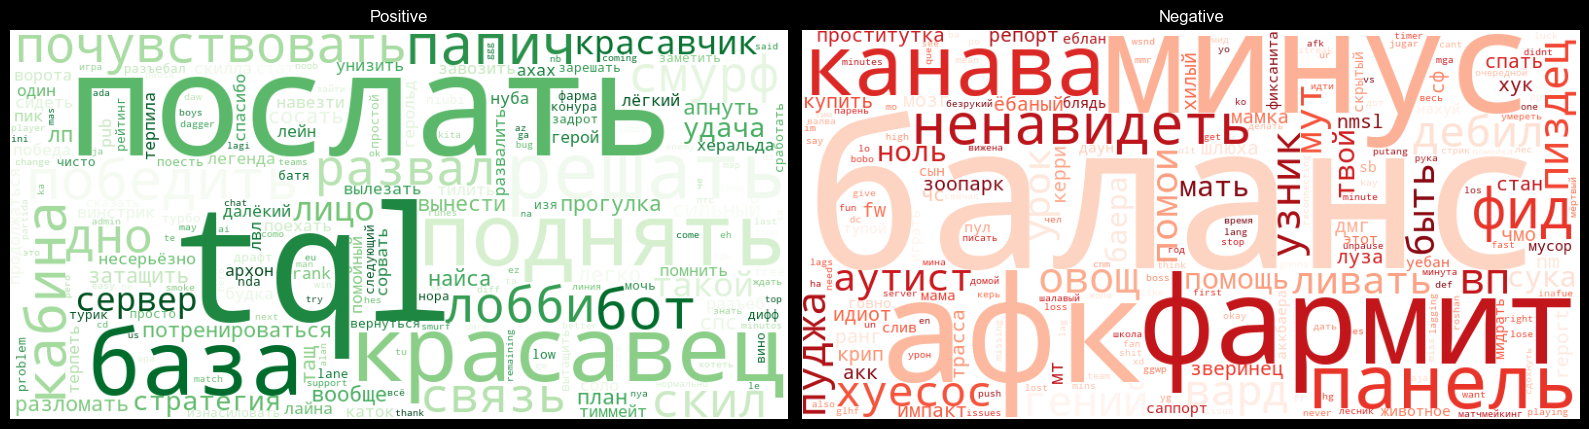

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_smapling_weights = word_weights.sort('radiant_weight', descending=True).select(pl.col('feature').alias('word'),
                                                                                    pl.col('radiant_weight').alias(
                                                                                        'weight'))

pos = text_smapling_weights.filter(pl.col('weight') > 0)
pos_dict = dict(zip(pos['word'].to_list(), pos['weight'].to_list()))

neg = text_smapling_weights.filter(pl.col('weight') < 0)
neg_dict = dict(zip(neg['word'].to_list(), (-neg['weight']).to_list()))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens').generate_from_frequencies(pos_dict)
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds').generate_from_frequencies(neg_dict)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_pos)
axes[0].set_title('Positive')
axes[0].axis('off')

axes[1].imshow(wc_neg)
axes[1].set_title('Negative')
axes[1].axis('off')

plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #ff748c; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что думаете? Сейчас и вообще по модели — негативные получились слова или так, едва?

**Ответ:**

</div>

In [23]:
import optuna

base_text_tune_config = LearnConfig("text_tune")
base_text_tune_config.add_group("base_cat", ["region", "game_mode"], categorical=True)
base_text_tune_config.add_group("mmr", ["avg_mmr"], scaling=True)
base_text_tune_config.add_group("flags", ["mmr_missing", "radiant_chat_is_empty", "dire_chat_is_empty"])
base_text_tune_config.add_hero_feature()

def objective_text_feature(trial):
    cfg = base_text_tune_config.clone()
    cfg.suggest_text_feature(trial, max_features_range=(250, 5000))
    cfg.suggest_model(trial)

    score = LearnPipeline(**cfg.pipeline_args()).evaluate(
        matchs_with_raw_chat_info, [],
        get_oot_split_mask(matchs_with_raw_chat_info)
    )[0]

    return score

best_text_score, best_text_params = storage.optimize("text_feature_tuning.v1", objective_text_feature, n_trials=50, verbose=True)

print(f'Best Gini: {best_text_score:.4f}')
print(f'Best params: {best_text_params}')

[text_feature_tuning.v1] cached: best Gini = 0.334282, params = {'use_radiant_chat': True, 'use_dire_chat': True, 'text_max_features': 2750, 'text_min_df': 36, 'text_max_df': 0.9142747876956004, 'text_sublinear_tf': True, 'text_ngram_max': 1, 'max_iter': 1224, 'C': 0.5220110445793957, 'solver': 'liblinear'}
Best Gini: 0.3343
Best params: {'use_radiant_chat': True, 'use_dire_chat': True, 'text_max_features': 2750, 'text_min_df': 36, 'text_max_df': 0.9142747876956004, 'text_sublinear_tf': True, 'text_ngram_max': 1, 'max_iter': 1224, 'C': 0.5220110445793957, 'solver': 'liblinear'}


### **Часть 5. Агрегации** (1.75 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">

В которой студент начинает ведать

#### 📈 **Задание 5.1. Статистики матча** (0.75 балла)

Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть *нюансы* — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут

In [24]:
match_adv_raw_df = pl.read_csv('data/dota_adv.csv')
match_adv_raw_df.head(3)

match_id,radiant_gold_adv,radiant_exp_adv
i64,str,str
526846,"""[ 0 159 452 1904 2100 3290…","""[ 0 68 658 1397 1435 2118…"
511496,"""[ 0 -151 -141 12 -165 -151…","""[ 0 1 -136 243 -270 -8…"
90272,"""[]""","""[]"""


In [25]:
import re


def parse_adv(s):
    if s is None or s == "[]":
        return None
    numbers = re.findall(r'-?\d+', s)
    return [int(x) for x in numbers]


match_adv_df = match_adv_raw_df.with_columns(
    pl.col('radiant_gold_adv').map_elements(parse_adv, return_dtype=pl.List(pl.Int64)),
    pl.col('radiant_exp_adv').map_elements(parse_adv, return_dtype=pl.List(pl.Int64))
)

match_adv_df.head(5)

match_id,radiant_gold_adv,radiant_exp_adv
i64,list[i64],list[i64]
526846,"[0, 159, … 5342]","[0, 68, … 3311]"
511496,"[0, -151, … 3698]","[0, 1, … 201]"
90272,null,null
153647,null,null
694826,null,null


In [26]:
adv_counter_df = match_adv_df.with_columns(pl.col('radiant_gold_adv').list.len().alias('gold_adv_len'),
                                           pl.col('radiant_exp_adv').list.len().alias('exp_adv_len'))

In [27]:
adv_counter_df['gold_adv_len'].value_counts()

gold_adv_len,count
u32,u32
null,529783
16,238039


In [28]:
adv_counter_df['exp_adv_len'].value_counts()

exp_adv_len,count
u32,u32
16,238039
null,529783


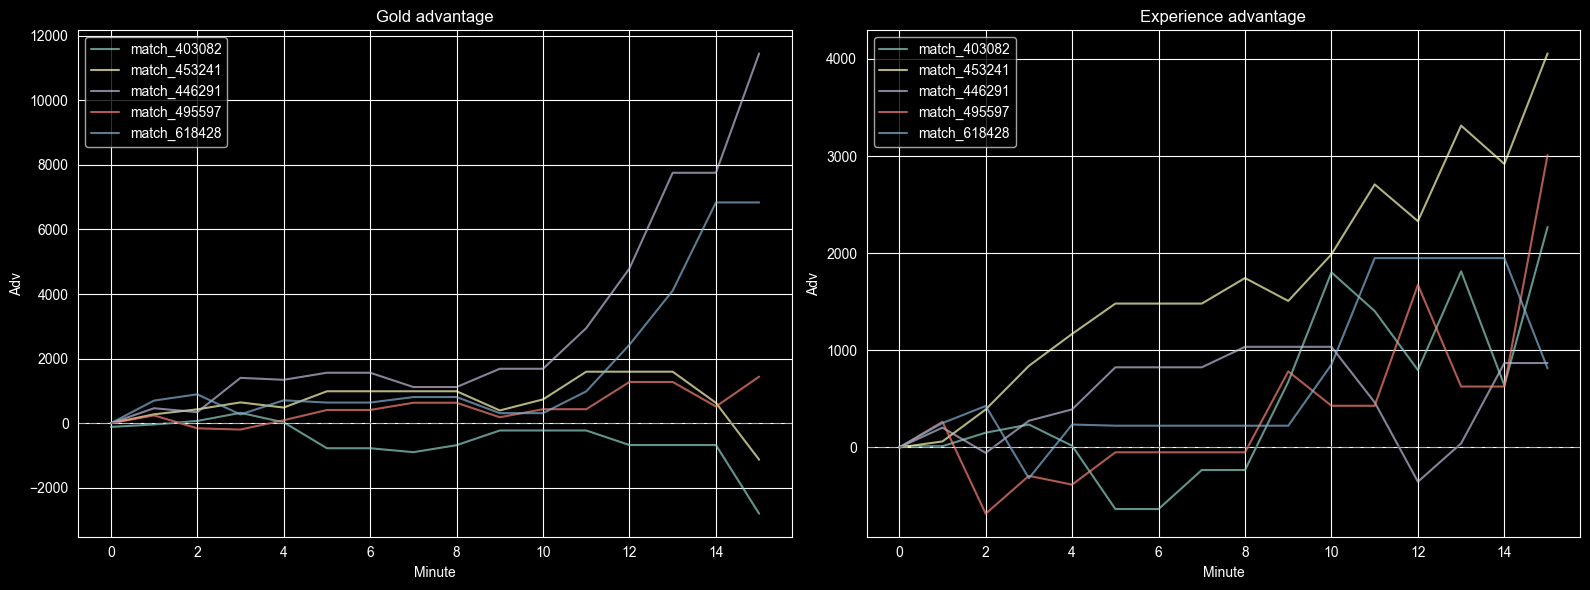

In [29]:
not_null_adv_df = match_adv_df.filter(
    pl.col('radiant_gold_adv').is_not_null() & pl.col('radiant_exp_adv').is_not_null())
adv_samples_df = not_null_adv_df.sample(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
adv_minutes = [i for i in range(16)]


def draw_samples_adv(ax, df: pl.DataFrame, adv_col: str, title: str):
    for row in df.iter_rows(named=True):
        ax.plot(adv_minutes, row[adv_col], alpha=0.7, label=f'match_{row["match_id"]}')
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel('Minute')
    ax.set_ylabel('Adv')
    ax.legend()


draw_samples_adv(axes[0], adv_samples_df, 'radiant_gold_adv', 'Gold advantage')
draw_samples_adv(axes[1], adv_samples_df, 'radiant_exp_adv', 'Experience advantage')
plt.tight_layout()
plt.show()

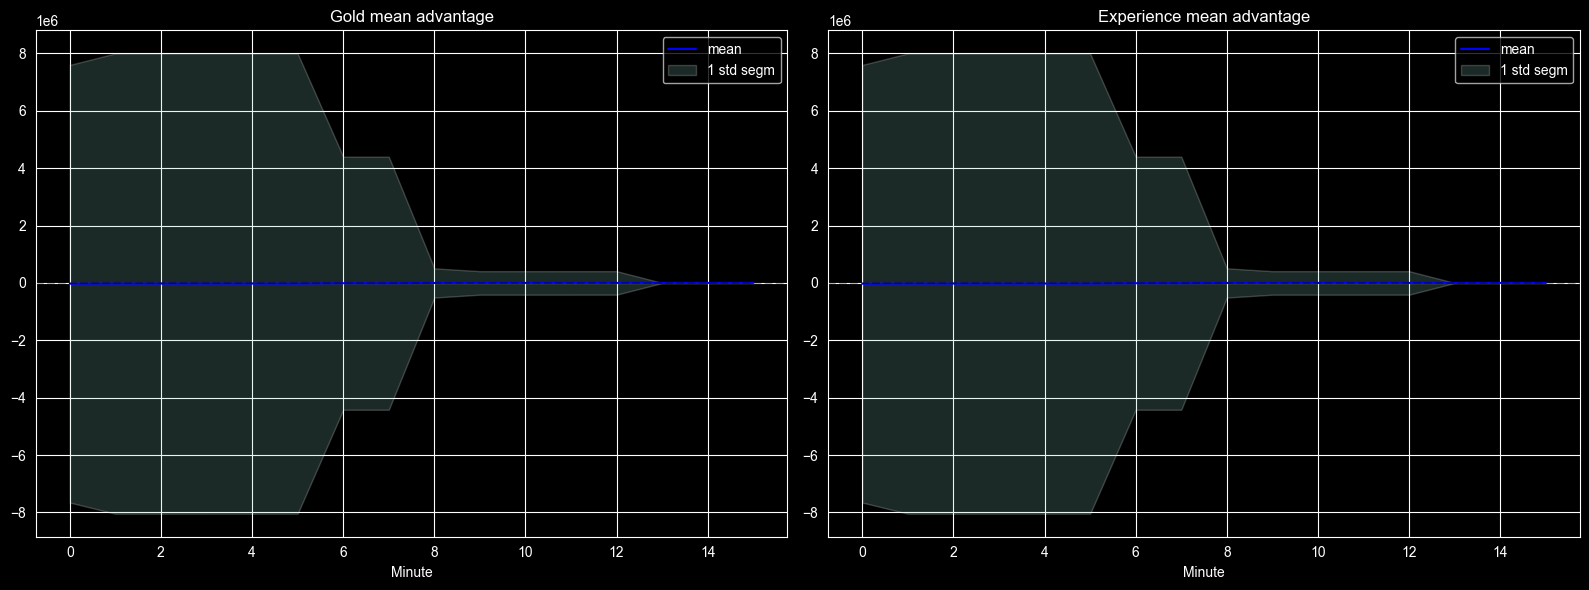

In [30]:
import numpy as np


def draw_mean_adv(ax, df: pl.DataFrame, adv_col: str, title: str):
    gold_matrix = np.array(df['radiant_gold_adv'].to_list())
    mean = gold_matrix.mean(axis=0)
    std = gold_matrix.std(axis=0)

    ax.plot(adv_minutes, mean, color='blue', label='mean')
    ax.fill_between(adv_minutes, mean - std, mean + std, alpha=0.2, label='1 std segm')
    ax.axhline(0, color='black', linestyle='--', alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel('Minute')
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

draw_mean_adv(axes[0], not_null_adv_df, 'radiant_gold_adv', 'Gold mean advantage')
draw_mean_adv(axes[1], not_null_adv_df, 'radiant_exp_adv', 'Experience mean advantage')
plt.tight_layout()
plt.show()

In [31]:
exploded_gold_adv_df = not_null_adv_df.select(pl.col('radiant_gold_adv')).explode('radiant_gold_adv')
exploded_exp_adv_df = not_null_adv_df.select(pl.col('radiant_exp_adv')).explode('radiant_exp_adv')

In [32]:
min_gold_adv = exploded_gold_adv_df['radiant_gold_adv'].min()
max_gold_adv = exploded_gold_adv_df['radiant_gold_adv'].max()
min_exp_adv = exploded_exp_adv_df['radiant_exp_adv'].min()
max_exp_adv = exploded_exp_adv_df['radiant_exp_adv'].max()
print(f'{min_gold_adv=}\n{max_gold_adv=}\n{min_exp_adv=}\n{max_exp_adv=}')

min_gold_adv=-2147383650
max_gold_adv=1214126263
min_exp_adv=-32400
max_exp_adv=66705


In [33]:
lower_gold_adv = exploded_gold_adv_df['radiant_gold_adv'].quantile(0.01)
upper_gold_adv = exploded_gold_adv_df['radiant_gold_adv'].quantile(0.99)
lower_exp_adv = exploded_exp_adv_df['radiant_exp_adv'].quantile(0.01)
upper_exp_adv = exploded_exp_adv_df['radiant_exp_adv'].quantile(0.99)
print(f'{lower_gold_adv=}\n{upper_gold_adv=}\n{lower_exp_adv=}\n{upper_exp_adv=}')

lower_gold_adv=-4304.0
upper_gold_adv=5638.0
lower_exp_adv=-3945.0
upper_exp_adv=5247.0


In [34]:
match_clipped_adv_df = match_adv_df.with_columns(
    pl.col('radiant_gold_adv').list.eval(
        pl.element().clip(lower_gold_adv, upper_gold_adv),
    ),
    pl.col('radiant_exp_adv').list.eval(
        pl.element().clip(lower_exp_adv, upper_exp_adv),
    )
)

match_clipped_adv_df.head(5)

match_id,radiant_gold_adv,radiant_exp_adv
i64,list[i64],list[i64]
526846,"[0, 159, … 5342]","[0, 68, … 3311]"
511496,"[0, -151, … 3698]","[0, 1, … 201]"
90272,null,null
153647,null,null
694826,null,null


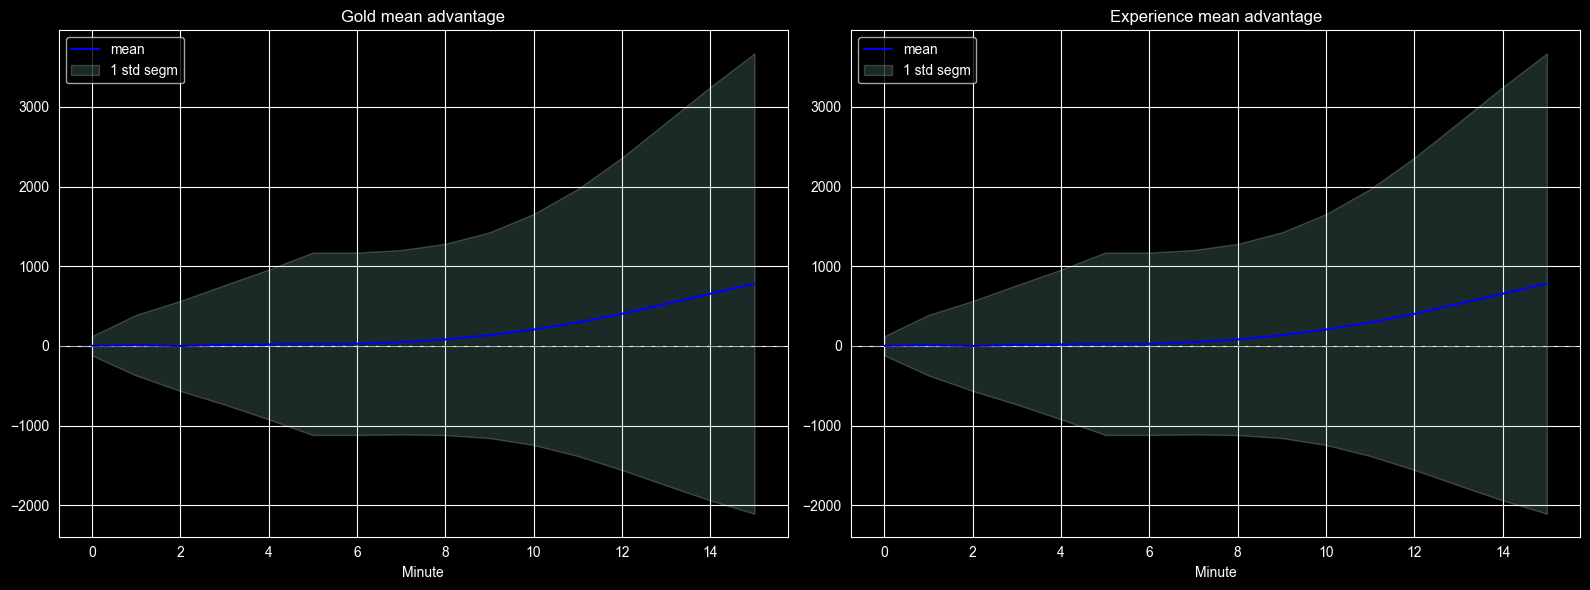

In [35]:
not_null_clipped_adv_df = match_clipped_adv_df.filter(
    pl.col('radiant_gold_adv').is_not_null() & pl.col('radiant_exp_adv').is_not_null())
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

draw_mean_adv(axes[0], not_null_clipped_adv_df, 'radiant_gold_adv', 'Gold mean advantage')
draw_mean_adv(axes[1], not_null_clipped_adv_df, 'radiant_exp_adv', 'Experience mean advantage')
plt.tight_layout()
plt.show()

In [36]:
match_clipped_adv_df['match_id'].value_counts().sort('count', descending=True).head(5)

match_id,count
i64,u32
208929,1
748586,1
673416,1
622200,1
18367,1


Для начала возьмём простые агрегации. Можете взять те, что вам знакомы (статистики - среднее, стд и др.), можете взять фан факты в вашей любимой библиотеке для данных, например [тут](https://pandas.pydata.org/docs/user_guide/groupby.html#aggregation) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html).

Задание:
- взять 4 статистики из библиотеки, применить к обеим колонкам `_adv`, <font color="#f68c9d">**обдумать**</font>, почему именно они
- одну из статистику выше разбить по командам, и точно так же примените к колонкам (получится что-то типа `agg_xp` -> `agg_dire_xp`, `agg_radiant_xp`)

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Тут мы встаём на скользкую дорожку переобучения. Агрегаций можно сделать **очень** много. Добавьте их все, и ваша модель превратится в тыкву. Удобнее будет сразу бить их на группы, например `features_last`, `features_q25`, `features_kurtosis_dire_10min+` и так далее, в зависимости от степени упоротости

C другой стороны, агрегации это самая сильная группа фичей, и для десяточки лучше целиться именно в них

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какие агрегации берём?

**Ответ:**
* Last - агрегация, будет полезна так как последнее значение по сути самое влиятельное
* Mean - агрегация, уравнивает выбросы, служит как подавление Last-аргегации выбросов
* Weight Mean - агрегация, взвешанное среднее где 0-й минуте дается меньше вес чем последней
* Count positie - Получаем сколько раз radiant доминировали над dire
* Max - Last - агрегация получаем как команда воспользовалась своим прейсуществом на пике
* Mean(11..15) - Mean(0..10) - на сколько команда выросла
* Last / (1 + std) - нормирует по мере того на сколько можно доверять значениям
* Mean / (1 + std) - нормирует по мере того на сколько можно доверять значениям
</div>

Обучите модель по агрегациям (одной группе или нескольким) + предыдущим фичам. Чтобы получить фулл балл, придётся показать, что хотя бы минимальный импрув есть, относительно бейзлайна

In [37]:
adv_agg_weights = [i for i in range(1, 17)]
adv_agg_weights_norm = sum(adv_agg_weights)
agg_features = match_clipped_adv_df.select(
    pl.col('match_id'),
    pl.col('radiant_gold_adv').list.last().alias('adv_last_gold').fill_null(pl.lit(0, pl.Int64)),
    pl.col('radiant_exp_adv').list.last().alias('adv_last_xp').fill_null(pl.lit(0, pl.Int64)),
    pl.col('radiant_gold_adv').list.mean().alias('adv_mean_gold').fill_null(pl.lit(0, pl.Float32)),
    pl.col('radiant_exp_adv').list.mean().alias('adv_mean_xp').fill_null(pl.lit(0, pl.Float32)),
    (pl.col('radiant_gold_adv').list.eval(
        pl.element() * pl.Series(adv_agg_weights)).list.sum() / adv_agg_weights_norm).alias(
        'adv_weighted_mean_gold').fill_null(pl.lit(0, pl.Float32)),
    (pl.col('radiant_exp_adv').list.eval(
        pl.element() * pl.Series(adv_agg_weights)).list.sum() / adv_agg_weights_norm).alias(
        'adv_weighted_mean_xp').fill_null(pl.lit(0, pl.Float32)),
    pl.col('radiant_gold_adv').list.eval(pl.element().gt(0).sum()).list.first().alias('adv_positive_gold').fill_null(
        pl.lit(0, pl.Int16)),
    pl.col('radiant_exp_adv').list.eval(pl.element().gt(0).sum()).list.first().alias('adv_positive_xp').fill_null(
        pl.lit(0, pl.Int16)),
    (pl.col('radiant_gold_adv').list.max() - pl.col('radiant_gold_adv').list.mean()).alias(
        'adv_max_last_diff_gold').fill_null(pl.lit(0, pl.Float32)),
    (pl.col('radiant_exp_adv').list.max() - pl.col('radiant_exp_adv').list.mean()).alias(
        'adv_max_last_diff_xp').fill_null(pl.lit(0, pl.Float32)),
    (pl.col('radiant_gold_adv').list.slice(0, 10).list.mean() - pl.col('radiant_gold_adv').list.slice(10,
                                                                                                      6).list.mean()).alias(
        'first_second_half_diff_gold').fill_null(pl.lit(0, pl.Float32)),
    (pl.col('radiant_exp_adv').list.slice(0, 10).list.mean() - pl.col('radiant_exp_adv').list.slice(10,
                                                                                                    6).list.mean()).alias(
        'first_second_half_diff_xp').fill_null(pl.lit(0, pl.Float32)),
    (pl.col('radiant_gold_adv').list.last() / (pl.col('radiant_gold_adv').list.std() + 1)).alias(
        'adv_last_norm_gold').fill_null(pl.lit(0, pl.Float32)),
    (pl.col('radiant_exp_adv').list.last() / (pl.col('radiant_exp_adv').list.std() + 1)).alias(
        'adv_last_norm_xp').fill_null(pl.lit(0, pl.Float32)),
    (pl.col('radiant_gold_adv').list.mean() / (pl.col('radiant_gold_adv').list.std() + 1)).alias(
        'adv_mean_norm_gold').fill_null(pl.lit(0, pl.Float32)),
    (pl.col('radiant_exp_adv').list.mean() / (pl.col('radiant_exp_adv').list.std() + 1)).alias(
        'adv_mean_norm_xp').fill_null(pl.lit(0, pl.Float32)),
    pl.col('radiant_gold_adv').is_null().alias('adv_null_gold'),
    pl.col('radiant_exp_adv').is_null().alias('adv_null_xp'),
)
agg_features.head(5)

match_id,adv_last_gold,adv_last_xp,adv_mean_gold,adv_mean_xp,adv_weighted_mean_gold,adv_weighted_mean_xp,adv_positive_gold,adv_positive_xp,adv_max_last_diff_gold,adv_max_last_diff_xp,first_second_half_diff_gold,first_second_half_diff_xp,adv_last_norm_gold,adv_last_norm_xp,adv_mean_norm_gold,adv_mean_norm_xp,adv_null_gold,adv_null_xp
i64,i64,i64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool
526846,5342,3311,2887.5,2262.25,3648.470588,2968.477941,15,15,2454.5,2398.75,-1930.933333,-2415.866667,3.315577,2.285662,1.792162,1.561685,false,false
511496,3698,201,933.875,191.625,1574.338235,298.970588,10,9,2764.125,739.375,-2507.933333,-599.0,2.664648,0.503739,0.672917,0.480243,false,false
90272,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
153647,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
694826,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true


In [38]:
print('adv shape: ', agg_features.shape)
print('train shape: ', train_matches_df.shape)
train_agg_features = agg_features.join(train_matches_df, on='match_id', how='semi')
print('adv shape after semi join: ', train_agg_features.shape)
print('null gold adv:', agg_features['adv_null_gold'].sum())

adv shape:  (767822, 19)
train shape:  (635457, 9)
adv shape after semi join:  (635457, 19)
null gold adv: 529783


In [39]:
train_with_agg_df = train_matches_df.join(agg_features, on='match_id', how='left')

train_with_agg_df.head(40)

match_id,avg_mmr,mmr_missing,game_mode,region,radiant_win,date,heroes_dire,heroes_radiant,adv_last_gold,adv_last_xp,adv_mean_gold,adv_mean_xp,adv_weighted_mean_gold,adv_weighted_mean_xp,adv_positive_gold,adv_positive_xp,adv_max_last_diff_gold,adv_max_last_diff_xp,first_second_half_diff_gold,first_second_half_diff_xp,adv_last_norm_gold,adv_last_norm_xp,adv_mean_norm_gold,adv_mean_norm_xp,adv_null_gold,adv_null_xp
i64,f64,bool,i64,str,bool,str,list[i64],list[i64],i64,i64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool
1,59.32706,false,4,"""Europe West""",false,"""2024-02-12""","[53, 5, … 13]","[65, 73, … 46]",0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
2,48.279395,false,2,"""South Africa""",true,"""2024-04-08""","[9, 50, … 51]","[106, 16, … 88]",0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
3,39.744182,false,1,"""SE Asia""",true,"""2024-06-16""","[42, 20, … 68]","[83, 28, … 11]",0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
4,53.355881,true,22,"""Middle East""",false,"""2024-09-16""","[27, 13, … 11]","[9, 47, … 89]",0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
5,53.355881,true,22,"""South Africa""",true,"""2024-03-31""","[40, 72, … 46]","[11, 68, … 7]",0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
43,41.572828,false,1,"""Middle East""",false,"""2024-08-27""","[75, 69, … 84]","[33, 1, … 17]",0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
44,70.47198,false,1,"""SE Asia""",false,"""2024-07-19""","[98, 19, … 15]","[97, 70, … 76]",0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
45,66.008333,false,22,"""SE Asia""",false,"""2024-01-10""","[45, 29, … 84]","[86, 80, … 69]",0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true


In [40]:
adv_agg_feature_groups = {
    'adv_last': ['adv_last_gold', 'adv_last_xp'],
    'adv_mean': ['adv_mean_gold', 'adv_mean_xp'],
    'adv_weighted_mean': ['adv_weighted_mean_gold', 'adv_weighted_mean_xp'],
    'adv_positive': ['adv_positive_gold', 'adv_positive_xp'],
    'adv_max_last_diff': ['adv_max_last_diff_gold', 'adv_max_last_diff_xp'],
    'adv_half_diff': ['first_second_half_diff_gold', 'first_second_half_diff_xp'],
    'adv_sharpe_last': ['adv_last_norm_gold', 'adv_last_norm_xp'],
    'adv_sharpe_mean': ['adv_mean_norm_gold', 'adv_mean_norm_xp'],
}

FEATURES_COLS_AGG = [col for cols in adv_agg_feature_groups.values() for col in cols]

base_agg_config = LearnConfig("base_agg_tune")
base_agg_config.add_group("base_cat", ["region", "game_mode"], categorical=True)
base_agg_config.add_group("mmr", ["avg_mmr"], scaling=True)
base_agg_config.add_group("flags", ["mmr_missing"])
base_agg_config.add_group("adv_flags", ["adv_null_gold", "adv_null_xp"])
for adv_feature, cols_names in adv_agg_feature_groups.items():
    base_agg_config.add_group(adv_feature, cols_names, scaling=True)
base_agg_config.add_hero_feature()

def objective_agg(trial):
    cfg = base_agg_config.clone()
    cfg.suggest_group_toggles(trial, list(adv_agg_feature_groups.keys()))
    cfg.suggest_model(trial)

    learning = LearnPipeline(**cfg.pipeline_args())
    return learning.evaluate(
        train_with_agg_df, [],
        get_oot_split_mask(train_with_agg_df)
    )[0]

best_agg_score, best_agg_params = storage.optimize("tune_base_agg_v1", objective_agg, n_trials=50)
print(f'Best Gini: {best_agg_score:.4f}')
print(f'Best params: {best_agg_params}')

FEATURES_COLS_AGG_FILTERED = []
for param, param_value in best_agg_params.items():
    if param_value and param.startswith('use_') and param[4:] in adv_agg_feature_groups:
        FEATURES_COLS_AGG_FILTERED.extend(adv_agg_feature_groups[param[4:]])
FEATURES_COLS_AGG_FILTERED

[tune_base_agg_v1] cached: best Gini = 0.402101, params = {'use_adv_last': True, 'use_adv_mean': True, 'use_adv_weighted_mean': False, 'use_adv_positive': False, 'use_adv_max_last_diff': True, 'use_adv_half_diff': True, 'use_adv_sharpe_last': True, 'use_adv_sharpe_mean': False, 'max_iter': 1017, 'C': 9.732364397180843, 'solver': 'saga'}
Best Gini: 0.4021
Best params: {'use_adv_last': True, 'use_adv_mean': True, 'use_adv_weighted_mean': False, 'use_adv_positive': False, 'use_adv_max_last_diff': True, 'use_adv_half_diff': True, 'use_adv_sharpe_last': True, 'use_adv_sharpe_mean': False, 'max_iter': 1017, 'C': 9.732364397180843, 'solver': 'saga'}


['adv_last_gold',
 'adv_last_xp',
 'adv_mean_gold',
 'adv_mean_xp',
 'adv_max_last_diff_gold',
 'adv_max_last_diff_xp',
 'first_second_half_diff_gold',
 'first_second_half_diff_xp',
 'adv_last_norm_gold',
 'adv_last_norm_xp']

#### 📈 **Задание 5.2. Тренд** (0.5 балла)

Каждый уважающий себя лудоман знает, что 99% процентов игроков останавливается ровно перед тем, как сорвать джекпот. Так и здесь — если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее — она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

<span style="color:grey"><font size="1">Администрация курса МО-1 категорически против азартных игр, пример приводится сугубо в образовательных целях.</font></span>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** для чего нам вообще тренд? Полезная ли это агрегация?

**Ответ:**

</div>

Агрегировать можно и вещи несколько более прикольные, чем те, что есть в основном функционале. Делать это мы будем, как вы наверняка догадались, трансформером, ну а чем же ещё. Что он умеет?

1. Принимает на вход функцию колонку и <font color="#cb9255">**параметры**</font> на ваш вкус, как минимум `method`, метод расчёта `slope`
2. Выделяет коэффициент наклона (`slope`, он же $\alpha$) при помощи одного из методов:
   - `'delta'`: разность первого и последнего значений $|x_{\max} - x_{\min}|$
   - `'OLS'`: линейная регрессия, обученная методом МНК $(X^TX)^{-1}X^Ty$
   - альтернативный метод, порождённый вашей бурной фантазией
3. Считает `r2` и `intercept` для одного advantage (если что это тоже могут быть наши фичи!)

In [41]:
from typing import Iterable


class TrendTransformer:
    def __init__(self, columns: Iterable[str]):
        self.columns = columns

    def fit(self, X, y=None):
        pass

    def _vectorized_transform(self, X: np.ndarray):
        rows_count, point_count = X.shape
        t = np.arange(point_count, dtype=np.float64)
        t_mean = t.mean()
        y_mean = X.mean(axis=1, keepdims=True)
        t_sq_dom = ((t - t_mean) ** 2).sum()

        res_slope = ((t - t_mean) * (X - y_mean)).sum(axis=1) / t_sq_dom
        res_intercept = y_mean.flatten() - res_slope * t_mean

        predictions = res_slope[:, None] * t[None, :] + res_intercept[:, None]

        sq_err = ((X - predictions) ** 2).sum(axis=1)
        sq_std = ((X - y_mean) ** 2).sum(axis=1)
        r2 = np.where(sq_std > 0, 1 -
                      np.divide(sq_err, sq_std, where=sq_std > 0, out=np.zeros_like(sq_err)), 0.)
        return res_slope, res_intercept, r2

    def transform(self, X: pl.DataFrame):
        new_features = X.select(pl.col('match_id'))
        for col_name in self.columns:
            X_null_filtered = X.filter(~pl.col(col_name).is_null())
            col_list = X_null_filtered[col_name].to_list()
            np_matrix = np.array(col_list, dtype=np.float64)

            slope_arr, intercept_arr, r2_arr = self._vectorized_transform(np_matrix)

            res_features_df = pl.DataFrame({
                'match_id': X_null_filtered['match_id'],
                f'{col_name}_slope': slope_arr.astype(np.float32),
                f'{col_name}_intercept': intercept_arr.astype(np.float32),
                f'{col_name}_r2': r2_arr.astype(np.float32)
            })

            new_features = new_features.join(res_features_df, on='match_id', how='left')

        return X.join(new_features, on='match_id', how='left')



Реализуйте трансформер. Критерий успеха, вновь, качество — фича должна помочь, хотя бы на долю пункта

In [42]:
default_trend_transformer = TrendTransformer(['radiant_gold_adv', 'radiant_exp_adv'])
adv_trend_features = default_trend_transformer.transform(match_clipped_adv_df)
adv_trend_features.head(5)

match_id,radiant_gold_adv,radiant_exp_adv,radiant_gold_adv_slope,radiant_gold_adv_intercept,radiant_gold_adv_r2,radiant_exp_adv_slope,radiant_exp_adv_intercept,radiant_exp_adv_r2
i64,list[i64],list[i64],f32,f32,f32,f32,f32,f32
526846,"[0, 159, … 5342]","[0, 68, … 3311]",304.388245,604.588257,0.810015,282.49118,143.566177,0.863183
511496,"[0, -151, … 3698]","[0, 1, … 201]",256.185303,-987.514709,0.773514,42.938236,-130.411758,0.2638
90272,null,null,null,null,null,null,null,null
153647,null,null,null,null,null,null,null,null
694826,null,null,null,null,null,null,null,null


In [43]:
adv_trend_processed_features = adv_trend_features.select(
    pl.col('match_id'),
    pl.col('radiant_gold_adv_slope').alias('gold_slope').fill_null(pl.lit(0, pl.Float32)),
    pl.col('radiant_exp_adv_slope').alias('xp_slope').fill_null(pl.lit(0, pl.Float32)),
    pl.col('radiant_gold_adv_intercept').alias('gold_intercept').fill_null(pl.lit(0, pl.Float32)),
    pl.col('radiant_exp_adv_intercept').alias('xp_intercept').fill_null(pl.lit(0, pl.Float32)),
    (pl.col('radiant_gold_adv_slope') * pl.col('radiant_gold_adv_r2')).alias('gold_slope_norm').fill_null(
        pl.lit(0, pl.Float32)),
    (pl.col('radiant_exp_adv_slope') * pl.col('radiant_exp_adv_r2')).alias('xp_slope_norm').fill_null(
        pl.lit(0, pl.Float32)),
    pl.col('radiant_gold_adv').is_null().alias('gold_null'),
    pl.col('radiant_exp_adv').is_null().alias('xp_null'),
)
adv_trend_processed_features.head()

match_id,gold_slope,xp_slope,gold_intercept,xp_intercept,gold_slope_norm,xp_slope_norm,gold_null,xp_null
i64,f32,f32,f32,f32,f32,f32,bool,bool
526846,304.388245,282.49118,604.588257,143.566177,246.559021,243.841614,false,false
511496,256.185303,42.938236,-987.514709,-130.411758,198.162903,11.327088,false,false
90272,0.0,0.0,0.0,0.0,0.0,0.0,true,true
153647,0.0,0.0,0.0,0.0,0.0,0.0,true,true
694826,0.0,0.0,0.0,0.0,0.0,0.0,true,true


In [44]:
train_with_adv_trend = train_matches_df.join(adv_trend_processed_features, on='match_id', how='left')
train_with_adv_trend.head(40)

match_id,avg_mmr,mmr_missing,game_mode,region,radiant_win,date,heroes_dire,heroes_radiant,gold_slope,xp_slope,gold_intercept,xp_intercept,gold_slope_norm,xp_slope_norm,gold_null,xp_null
i64,f64,bool,i64,str,bool,str,list[i64],list[i64],f32,f32,f32,f32,f32,f32,bool,bool
1,59.32706,false,4,"""Europe West""",false,"""2024-02-12""","[53, 5, … 13]","[65, 73, … 46]",0.0,0.0,0.0,0.0,0.0,0.0,true,true
2,48.279395,false,2,"""South Africa""",true,"""2024-04-08""","[9, 50, … 51]","[106, 16, … 88]",0.0,0.0,0.0,0.0,0.0,0.0,true,true
3,39.744182,false,1,"""SE Asia""",true,"""2024-06-16""","[42, 20, … 68]","[83, 28, … 11]",0.0,0.0,0.0,0.0,0.0,0.0,true,true
4,53.355881,true,22,"""Middle East""",false,"""2024-09-16""","[27, 13, … 11]","[9, 47, … 89]",0.0,0.0,0.0,0.0,0.0,0.0,true,true
5,53.355881,true,22,"""South Africa""",true,"""2024-03-31""","[40, 72, … 46]","[11, 68, … 7]",0.0,0.0,0.0,0.0,0.0,0.0,true,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
43,41.572828,false,1,"""Middle East""",false,"""2024-08-27""","[75, 69, … 84]","[33, 1, … 17]",0.0,0.0,0.0,0.0,0.0,0.0,true,true
44,70.47198,false,1,"""SE Asia""",false,"""2024-07-19""","[98, 19, … 15]","[97, 70, … 76]",0.0,0.0,0.0,0.0,0.0,0.0,true,true
45,66.008333,false,22,"""SE Asia""",false,"""2024-01-10""","[45, 29, … 84]","[86, 80, … 69]",0.0,0.0,0.0,0.0,0.0,0.0,true,true


In [45]:
import json

with open('data/artifacts/params1.jsonl', 'r', encoding='utf-8') as f:
    best_base_params = json.load(f)
print(best_base_params)

{'C': 4.095212110136731, 'solver': 'saga', 'max_iter': 813, 'gini': 0.3108072123434029}


In [46]:
default_base_C = best_base_params['C']
default_base_solver = best_base_params['solver']
default_base_max_iter = best_base_params['max_iter']
FEATURES_COLS_ADV_TREND = ['gold_slope', 'xp_slope', 'gold_intercept', 'xp_intercept', 'gold_slope_norm',
                           'xp_slope_norm']

learn_config_adv_trend = LearnConfig('config:hero,adv_trend')
learn_config_adv_trend.add_group("base_cat", ["region", "game_mode"], categorical=True)
learn_config_adv_trend.add_group("mmr", ["avg_mmr"], scaling=True)
learn_config_adv_trend.add_group("flags", ["mmr_missing"])
learn_config_adv_trend.add_group("trend", FEATURES_COLS_ADV_TREND, scaling=True)
learn_config_adv_trend.add_group("trend_flags", ["gold_null", "xp_null"])
learn_config_adv_trend.add_hero_feature()
learn_config_adv_trend.set_model(LogisticRegression, C = default_base_C, max_iter = default_base_max_iter, solver = default_base_solver)

train_with_adv_trend_score = storage.evaluate("features:hero,adv_trend", learn_config_adv_trend, train_with_adv_trend,
                          get_oot_split_mask(train_with_adv_trend), verbose=True)

  [features:hero,adv_trend] cached: Gini = 0.393824


In [47]:
print(f"training on advanages trends score: {train_with_adv_trend_score:.4f}")

training on advanages trends score: 0.3938


#### **📈 Задание 5.3. Бинаризация** (0.5 балла)

Ровно одну прикольную фишку для числовых признаков мы пока что не рассмотрели — бинаризацию. Если вы до неё уже догадались, то вы — гений, не думали на <font color="cb9255">**МОП**</font>? А если нет, суть такова:

1. Берём отрезок advantage и бьём его на несколько бинов
2. Бины можно использовать, как фичу саму по себе, а можно подсобрать внутри неё агрегации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Во-первых, ваша модель внезапно становится нелинейной, хоть и кусочной, это полный отвал \
Во-вторых, это простейший пример ансамбля, если бинаризовать таргет (но у нас, увы нет смысла, он дискретный). Нелинейность полезна почему — в первые минуты преимущество не так решает, как в последние. \
В-третьих, это фильтрует шумный сигнал, выбросы то отлетят в соответствующий бин

</div>

Попробуем? Бинаризуйте признаки advantage: занумеруйте их (сделайте категорию) и посчитайте побиновые агрегации

In [48]:
ALL_ADV_BIN_COLUMNS = []
time_segments = {
    'begin': (0, 5),
    'mid': (5, 10),
    'end': (10, 16),
}

time_bin_agg_feature = match_clipped_adv_df
for time_bin, (start, end) in time_segments.items():
    gold_slice = pl.col(f'radiant_gold_adv').list.slice(start, end - start)
    xp_slice = pl.col(f'radiant_exp_adv').list.slice(start, end - start)
    time_bin_agg_feature = time_bin_agg_feature.with_columns([
        gold_slice.list.mean().alias(f'gold_mean_{time_bin}').fill_null(pl.lit(0, pl.Float32)),
        gold_slice.list.max().alias(f'gold_max_{time_bin}').fill_null(pl.lit(0, pl.Float32)),
        xp_slice.list.mean().alias(f'xp_mean_{time_bin}').fill_null(pl.lit(0, pl.Float32)),
        xp_slice.list.max().alias(f'xp_max_{time_bin}').fill_null(pl.lit(0, pl.Float32)),
    ])

time_bin_agg_feature = time_bin_agg_feature.drop('radiant_gold_adv')
time_bin_agg_feature = time_bin_agg_feature.drop('radiant_exp_adv')
FEATURES_COLS_TIME_BIN_AGG = list(filter(lambda col: col != 'match_id', time_bin_agg_feature.columns))
ALL_ADV_BIN_COLUMNS.extend(FEATURES_COLS_TIME_BIN_AGG)
time_bin_agg_feature.head()

match_id,gold_mean_begin,gold_max_begin,xp_mean_begin,xp_max_begin,gold_mean_mid,gold_max_mid,xp_mean_mid,xp_max_mid,gold_mean_end,gold_max_end,xp_mean_end,xp_max_end
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
526846,923.0,2100.0,711.6,1435.0,3403.8,3859.0,2001.0,2118.0,4094.333333,5342.0,3772.166667,4661.0
511496,-89.0,12.0,-32.4,243.0,75.8,377.0,-33.6,186.0,2501.333333,3698.0,566.0,931.0
90272,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
153647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
694826,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
tresholds = {
    'very_low': -2000,
    'low': -500,
    'zero': 0,
    'high': 500,
    'very_high': 2000
}
counter_above_tresholds_feature = match_clipped_adv_df
for th_name, tresh in tresholds.items():
    counter_above_tresholds_feature = counter_above_tresholds_feature.with_columns(
        pl.col(f'radiant_gold_adv').list.eval(pl.element() > tresh).list.sum().alias(f'gold_above_{th_name}').fill_null(
            pl.lit(0, pl.UInt32)),
        pl.col(f'radiant_exp_adv').list.eval(pl.element() > tresh).list.sum().alias(f'xp_above_{th_name}').fill_null(
            pl.lit(0, pl.UInt32))
    )

counter_above_tresholds_feature = counter_above_tresholds_feature.drop('radiant_gold_adv')
counter_above_tresholds_feature = counter_above_tresholds_feature.drop('radiant_exp_adv')
FEATURES_COLS_COUNTER_ABOVE_TH = list(filter(lambda col: col != 'match_id', counter_above_tresholds_feature.columns))
ALL_ADV_BIN_COLUMNS.extend(FEATURES_COLS_COUNTER_ABOVE_TH)

counter_above_tresholds_feature.head()

match_id,gold_above_very_low,xp_above_very_low,gold_above_low,xp_above_low,gold_above_zero,xp_above_zero,gold_above_high,xp_above_high,gold_above_very_high,xp_above_very_high
i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
526846,16,16,16,16,15,15,13,14,12,8
511496,16,16,16,16,10,9,6,3,5,0
90272,0,0,0,0,0,0,0,0,0,0
153647,0,0,0,0,0,0,0,0,0,0
694826,0,0,0,0,0,0,0,0,0,0


In [50]:
counter_above_tresholds_in_last_bin_feature = match_clipped_adv_df
for th_name, tresh in tresholds.items():
    counter_above_tresholds_in_last_bin_feature = counter_above_tresholds_in_last_bin_feature.with_columns(
        pl.col(f'radiant_gold_adv').list.slice(10, 6).list.eval(pl.element() > tresh).list.sum().alias(
            f'gold_above_{th_name}_last_bin').fill_null(
            pl.lit(0, pl.UInt32)),
        pl.col(f'radiant_exp_adv').list.slice(10, 6).list.eval(pl.element() > tresh).list.sum().alias(
            f'xp_above_{th_name}_last_bin').fill_null(
            pl.lit(0, pl.UInt32))
    )

counter_above_tresholds_in_last_bin_feature = counter_above_tresholds_in_last_bin_feature.drop('radiant_gold_adv')
counter_above_tresholds_in_last_bin_feature = counter_above_tresholds_in_last_bin_feature.drop('radiant_exp_adv')
FEATURES_COLS_COUNTER_ABOVE_TH_LAST_BIN = list(
    filter(lambda col: col != 'match_id', counter_above_tresholds_in_last_bin_feature.columns))
ALL_ADV_BIN_COLUMNS.extend(FEATURES_COLS_COUNTER_ABOVE_TH_LAST_BIN)
counter_above_tresholds_in_last_bin_feature.head(5)

match_id,gold_above_very_low_last_bin,xp_above_very_low_last_bin,gold_above_low_last_bin,xp_above_low_last_bin,gold_above_zero_last_bin,xp_above_zero_last_bin,gold_above_high_last_bin,xp_above_high_last_bin,gold_above_very_high_last_bin,xp_above_very_high_last_bin
i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
526846,6,6,6,6,6,6,6,6,6,6
511496,6,6,6,6,6,6,6,3,5,0
90272,0,0,0,0,0,0,0,0,0,0
153647,0,0,0,0,0,0,0,0,0,0
694826,0,0,0,0,0,0,0,0,0,0


In [51]:
null_adv_feature = match_clipped_adv_df.select(
    pl.col('match_id'),
    pl.col('radiant_gold_adv').is_null().alias('gold_null'),
    pl.col('radiant_exp_adv').is_null().alias('xp_null'),
)
null_adv_feature.head()

match_id,gold_null,xp_null
i64,bool,bool
526846,false,false
511496,false,false
90272,true,true
153647,true,true
694826,true,true


In [52]:
train_with_adv_bins = (train_matches_df
                       .join(time_bin_agg_feature, on='match_id', how='left')
                       .join(counter_above_tresholds_feature, on='match_id', how='left')
                       .join(counter_above_tresholds_in_last_bin_feature, on='match_id', how='left')
                       .join(null_adv_feature, on='match_id', how='left'))
print('bins features: ', ALL_ADV_BIN_COLUMNS)
train_with_adv_bins.head(40)

bins features:  ['gold_mean_begin', 'gold_max_begin', 'xp_mean_begin', 'xp_max_begin', 'gold_mean_mid', 'gold_max_mid', 'xp_mean_mid', 'xp_max_mid', 'gold_mean_end', 'gold_max_end', 'xp_mean_end', 'xp_max_end', 'gold_above_very_low', 'xp_above_very_low', 'gold_above_low', 'xp_above_low', 'gold_above_zero', 'xp_above_zero', 'gold_above_high', 'xp_above_high', 'gold_above_very_high', 'xp_above_very_high', 'gold_above_very_low_last_bin', 'xp_above_very_low_last_bin', 'gold_above_low_last_bin', 'xp_above_low_last_bin', 'gold_above_zero_last_bin', 'xp_above_zero_last_bin', 'gold_above_high_last_bin', 'xp_above_high_last_bin', 'gold_above_very_high_last_bin', 'xp_above_very_high_last_bin']


match_id,avg_mmr,mmr_missing,game_mode,region,radiant_win,date,heroes_dire,heroes_radiant,gold_mean_begin,gold_max_begin,xp_mean_begin,xp_max_begin,gold_mean_mid,gold_max_mid,xp_mean_mid,xp_max_mid,gold_mean_end,gold_max_end,xp_mean_end,xp_max_end,gold_above_very_low,xp_above_very_low,gold_above_low,xp_above_low,gold_above_zero,xp_above_zero,gold_above_high,xp_above_high,gold_above_very_high,xp_above_very_high,gold_above_very_low_last_bin,xp_above_very_low_last_bin,gold_above_low_last_bin,xp_above_low_last_bin,gold_above_zero_last_bin,xp_above_zero_last_bin,gold_above_high_last_bin,xp_above_high_last_bin,gold_above_very_high_last_bin,xp_above_very_high_last_bin,gold_null,xp_null
i64,f64,bool,i64,str,bool,str,list[i64],list[i64],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,bool,bool
1,59.32706,false,4,"""Europe West""",false,"""2024-02-12""","[53, 5, … 13]","[65, 73, … 46]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,true,true
2,48.279395,false,2,"""South Africa""",true,"""2024-04-08""","[9, 50, … 51]","[106, 16, … 88]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,true,true
3,39.744182,false,1,"""SE Asia""",true,"""2024-06-16""","[42, 20, … 68]","[83, 28, … 11]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,true,true
4,53.355881,true,22,"""Middle East""",false,"""2024-09-16""","[27, 13, … 11]","[9, 47, … 89]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,true,true
5,53.355881,true,22,"""South Africa""",true,"""2024-03-31""","[40, 72, … 46]","[11, 68, … 7]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,true,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
43,41.572828,false,1,"""Middle East""",false,"""2024-08-27""","[75, 69, … 84]","[33, 1, … 17]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,true,true
44,70.47198,false,1,"""SE Asia""",false,"""2024-07-19""","[98, 19, … 15]","[97, 70, … 76]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,true,true
45,66.008333,false,22,"""SE Asia""",false,"""2024-01-10""","[45, 29, … 84]","[86, 80, … 69]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,true,true


In [53]:
bin_config = LearnConfig("bins_v1")
bin_config.add_group("base_cat", ["region", "game_mode"], categorical=True)
bin_config.add_group("mmr", ["avg_mmr"], scaling=True)
bin_config.add_group("flags", ["mmr_missing"])
bin_config.add_group("bins", ALL_ADV_BIN_COLUMNS, scaling=True)
bin_config.add_group("bin_flags", ["gold_null", "xp_null"])
bin_config.add_hero_feature()
bin_config.set_model(LogisticRegression, C = default_base_C, max_iter = default_base_max_iter, solver = default_base_solver)

train_with_adv_bin_score  = storage.evaluate("bins_v1", bin_config, train_with_adv_bins,
                          get_oot_split_mask(train_with_adv_bins), verbose=True)

  [bins_v1] cached: Gini = 0.395566


In [54]:
print(train_with_adv_bin_score)

0.39556649


In [55]:
adv_feature_groups = adv_agg_feature_groups | {
    "adv_trend_features": FEATURES_COLS_ADV_TREND,
    "adv_bin_agg_features": FEATURES_COLS_TIME_BIN_AGG,
    "adv_counters_above_features": FEATURES_COLS_COUNTER_ABOVE_TH,
    "adv_counters_above_last_bin_features": FEATURES_COLS_COUNTER_ABOVE_TH_LAST_BIN,
}

In [56]:
adv_feature_groups

{'adv_last': ['adv_last_gold', 'adv_last_xp'],
 'adv_mean': ['adv_mean_gold', 'adv_mean_xp'],
 'adv_weighted_mean': ['adv_weighted_mean_gold', 'adv_weighted_mean_xp'],
 'adv_positive': ['adv_positive_gold', 'adv_positive_xp'],
 'adv_max_last_diff': ['adv_max_last_diff_gold', 'adv_max_last_diff_xp'],
 'adv_half_diff': ['first_second_half_diff_gold', 'first_second_half_diff_xp'],
 'adv_sharpe_last': ['adv_last_norm_gold', 'adv_last_norm_xp'],
 'adv_sharpe_mean': ['adv_mean_norm_gold', 'adv_mean_norm_xp'],
 'adv_trend_features': ['gold_slope',
  'xp_slope',
  'gold_intercept',
  'xp_intercept',
  'gold_slope_norm',
  'xp_slope_norm'],
 'adv_bin_agg_features': ['gold_mean_begin',
  'gold_max_begin',
  'xp_mean_begin',
  'xp_max_begin',
  'gold_mean_mid',
  'gold_max_mid',
  'xp_mean_mid',
  'xp_max_mid',
  'gold_mean_end',
  'gold_max_end',
  'xp_mean_end',
  'xp_max_end'],
 'adv_counters_above_features': ['gold_above_very_low',
  'xp_above_very_low',
  'gold_above_low',
  'xp_above_low',


# Самостаятельная часть

In [57]:
agg_with_text_features = matchs_with_raw_chat_info.join(agg_features, on='match_id', how='left')
agg_with_text_features.head()

match_id,avg_mmr,mmr_missing,game_mode,region,radiant_win,date,heroes_dire,heroes_radiant,radiant_chat,dire_chat,radiant_chat_is_empty,dire_chat_is_empty,adv_last_gold,adv_last_xp,adv_mean_gold,adv_mean_xp,adv_weighted_mean_gold,adv_weighted_mean_xp,adv_positive_gold,adv_positive_xp,adv_max_last_diff_gold,adv_max_last_diff_xp,first_second_half_diff_gold,first_second_half_diff_xp,adv_last_norm_gold,adv_last_norm_xp,adv_mean_norm_gold,adv_mean_norm_xp,adv_null_gold,adv_null_xp
i64,f64,bool,i64,str,bool,str,list[i64],list[i64],str,str,bool,bool,i64,i64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool
1,59.32706,false,4,"""Europe West""",false,"""2024-02-12""","[53, 5, … 13]","[65, 73, … 46]","""emoguess""","""""",false,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
2,48.279395,false,2,"""South Africa""",true,"""2024-04-08""","[9, 50, … 51]","[106, 16, … 88]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
3,39.744182,false,1,"""SE Asia""",true,"""2024-06-16""","[42, 20, … 68]","[83, 28, … 11]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
4,53.355881,true,22,"""Middle East""",false,"""2024-09-16""","[27, 13, … 11]","[9, 47, … 89]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
5,53.355881,true,22,"""South Africa""",true,"""2024-03-31""","[40, 72, … 46]","[11, 68, … 7]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true


In [58]:
FEATURES_COLS_AGG_FILTERED

['adv_last_gold',
 'adv_last_xp',
 'adv_mean_gold',
 'adv_mean_xp',
 'adv_max_last_diff_gold',
 'adv_max_last_diff_xp',
 'first_second_half_diff_gold',
 'first_second_half_diff_xp',
 'adv_last_norm_gold',
 'adv_last_norm_xp']

In [59]:
learn_config_with_adv_agg_and_chat = base_config_with_heroes.clone('learn_config:heroes,adv_agg,chat_info')
learn_config_with_adv_agg_and_chat.add_text_feature(TfidfVectorizer(max_df=0.95, min_df=30, max_features=5000),
                                                    use_dire_chat=True,
                                                    use_radiant_chat=True)

learn_config_with_adv_agg_and_chat.add_group('base_adv_agg', FEATURES_COLS_AGG_FILTERED + ['adv_null_gold', 'adv_null_xp'], scaling=True)

In [60]:
agg_with_text_features.select((pl.col('date').cast(pl.String)<"2024-11-01").alias('train'))['train'].value_counts()

train,count
bool,u32
false,58267
true,577190


In [61]:
adv_agg_chat_score = storage.evaluate('learn:adv_agg,chat', learn_config_with_adv_agg_and_chat, agg_with_text_features, get_oot_split_mask(agg_with_text_features), verbose=True)

  [learn:adv_agg,chat] cached: Gini = 0.419586


In [62]:
learn_config_with_adv_agg_trend_and_chat = base_config_with_heroes.clone('learn_config:heroes,adv_agg,adv_trend,chat_info')
learn_config_with_adv_agg_trend_and_chat.add_text_feature(TfidfVectorizer(max_df=0.95, min_df=30, max_features=5000),
                                                    use_dire_chat=True,
                                                    use_radiant_chat=True)
learn_config_with_adv_agg_trend_and_chat.add_group('base_adv_agg', FEATURES_COLS_AGG_FILTERED + ['adv_null_gold', 'adv_null_xp'], scaling=True)
learn_config_with_adv_agg_trend_and_chat.add_group('base_adv_trend', FEATURES_COLS_ADV_TREND, scaling=True)


In [63]:
adv_agg_trend_text_features = agg_with_text_features.join(adv_trend_processed_features.drop(['gold_null', 'xp_null']), on='match_id', how='left')
adv_agg_trend_text_features.head()

match_id,avg_mmr,mmr_missing,game_mode,region,radiant_win,date,heroes_dire,heroes_radiant,radiant_chat,dire_chat,radiant_chat_is_empty,dire_chat_is_empty,adv_last_gold,adv_last_xp,adv_mean_gold,adv_mean_xp,adv_weighted_mean_gold,adv_weighted_mean_xp,adv_positive_gold,adv_positive_xp,adv_max_last_diff_gold,adv_max_last_diff_xp,first_second_half_diff_gold,first_second_half_diff_xp,adv_last_norm_gold,adv_last_norm_xp,adv_mean_norm_gold,adv_mean_norm_xp,adv_null_gold,adv_null_xp,gold_slope,xp_slope,gold_intercept,xp_intercept,gold_slope_norm,xp_slope_norm
i64,f64,bool,i64,str,bool,str,list[i64],list[i64],str,str,bool,bool,i64,i64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,f32,f32,f32,f32,f32,f32
1,59.32706,false,4,"""Europe West""",false,"""2024-02-12""","[53, 5, … 13]","[65, 73, … 46]","""emoguess""","""""",false,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true,0.0,0.0,0.0,0.0,0.0,0.0
2,48.279395,false,2,"""South Africa""",true,"""2024-04-08""","[9, 50, … 51]","[106, 16, … 88]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true,0.0,0.0,0.0,0.0,0.0,0.0
3,39.744182,false,1,"""SE Asia""",true,"""2024-06-16""","[42, 20, … 68]","[83, 28, … 11]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true,0.0,0.0,0.0,0.0,0.0,0.0
4,53.355881,true,22,"""Middle East""",false,"""2024-09-16""","[27, 13, … 11]","[9, 47, … 89]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true,0.0,0.0,0.0,0.0,0.0,0.0
5,53.355881,true,22,"""South Africa""",true,"""2024-03-31""","[40, 72, … 46]","[11, 68, … 7]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true,0.0,0.0,0.0,0.0,0.0,0.0


In [64]:
adv_agg_trend_chat_score = storage.evaluate('learn:adv_agg,adv_trend,chat', learn_config_with_adv_agg_trend_and_chat, adv_agg_trend_text_features, get_oot_split_mask(adv_agg_trend_text_features), verbose=True)

  [learn:adv_agg,adv_trend,chat] cached: Gini = 0.419782


## Обучение для тестовой выборки модели с heroes-категориями, chat фичами и advantage agregation

In [65]:
hero_adv_agg_chat_features_learning = LearnPipeline(**learn_config_with_adv_agg_and_chat.pipeline_args())
hero_adv_agg_chat_features_learning.fit(agg_with_text_features, [], verbose=True)

fit on (635457, 1479) shape, df columns: ['match_id', 'avg_mmr', 'mmr_missing', 'game_mode', 'region', 'radiant_win', 'date', 'heroes_dire', 'heroes_radiant', 'radiant_chat', 'dire_chat', 'radiant_chat_is_empty', 'dire_chat_is_empty', 'adv_last_gold', 'adv_last_xp', 'adv_mean_gold', 'adv_mean_xp', 'adv_weighted_mean_gold', 'adv_weighted_mean_xp', 'adv_positive_gold', 'adv_positive_xp', 'adv_max_last_diff_gold', 'adv_max_last_diff_xp', 'first_second_half_diff_gold', 'first_second_half_diff_xp', 'adv_last_norm_gold', 'adv_last_norm_xp', 'adv_mean_norm_gold', 'adv_mean_norm_xp', 'adv_null_gold', 'adv_null_xp']


In [66]:
test_with_heroes_col_df = pl.read_parquet('data/artifacts/test_with_heroes_col_df.parquet')
test_matches_df = pl.read_csv('data/matches_df_test.csv')
test_with_heroes_col_df.head()

match_id,avg_mmr,mmr_missing,game_mode,region,date,heroes_radiant,heroes_dire
i64,f64,bool,i64,str,str,list[i64],list[i64]
8,48.010416,false,1,"""China""","""2024-12-01""","[77, 65, … 32]","[96, 84, … 90]"
29,52.71385,true,22,"""Europe West""","""2024-12-17""","[94, 68, … 75]","[25, 77, … 93]"
34,47.733636,false,22,"""Europe West""","""2024-12-19""","[100, 5, … 21]","[71, 74, … 15]"
36,17.487138,false,1,"""Europe West""","""2024-12-19""","[20, 36, … 32]","[29, 12, … 22]"
61,71.710529,false,1,"""Australia""","""2024-12-06""","[68, 33, … 110]","[51, 40, … 70]"


In [67]:
test_with_raw_chat_info = test_with_heroes_col_df.join(
    chat_preprocessed_df, on='match_id', how='left'
)

test_agg_adv_with_text = test_with_raw_chat_info.join(
    agg_features, on='match_id', how='left'
)

test_agg_adv_with_text.head(40)

match_id,avg_mmr,mmr_missing,game_mode,region,date,heroes_radiant,heroes_dire,radiant_chat,dire_chat,radiant_chat_is_empty,dire_chat_is_empty,adv_last_gold,adv_last_xp,adv_mean_gold,adv_mean_xp,adv_weighted_mean_gold,adv_weighted_mean_xp,adv_positive_gold,adv_positive_xp,adv_max_last_diff_gold,adv_max_last_diff_xp,first_second_half_diff_gold,first_second_half_diff_xp,adv_last_norm_gold,adv_last_norm_xp,adv_mean_norm_gold,adv_mean_norm_xp,adv_null_gold,adv_null_xp
i64,f64,bool,i64,str,str,list[i64],list[i64],str,str,bool,bool,i64,i64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool
8,48.010416,false,1,"""China""","""2024-12-01""","[77, 65, … 32]","[96, 84, … 90]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
29,52.71385,true,22,"""Europe West""","""2024-12-17""","[94, 68, … 75]","[25, 77, … 93]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
34,47.733636,false,22,"""Europe West""","""2024-12-19""","[100, 5, … 21]","[71, 74, … 15]","""marshal pwede ba mag salita ng…","""""",false,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
36,17.487138,false,1,"""Europe West""","""2024-12-19""","[20, 36, … 32]","[29, 12, … 22]","""laggy day today""","""""",false,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
61,71.710529,false,1,"""Australia""","""2024-12-06""","[68, 33, … 110]","[51, 40, … 70]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
449,58.943193,false,1,"""South America""","""2024-12-31""","[55, 47, … 1]","[44, 84, … 34]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
467,50.217527,false,1,"""Europe East""","""2024-12-04""","[75, 20, … 29]","[4, 45, … 72]","""""","""check emoguess""",true,false,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true
480,60.354784,false,1,"""Europe East""","""2024-12-29""","[35, 14, … 17]","[25, 26, … 28]","""""","""""",true,true,0,0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,true,true


In [68]:
hero_adv_agg_chat_features_predictions = hero_adv_agg_chat_features_learning.predict(test_agg_adv_with_text, [], verbose=True)

predict on (59748, 1479) shape, df columns: ['match_id', 'avg_mmr', 'mmr_missing', 'game_mode', 'region', 'date', 'heroes_radiant', 'heroes_dire', 'radiant_chat', 'dire_chat', 'radiant_chat_is_empty', 'dire_chat_is_empty', 'adv_last_gold', 'adv_last_xp', 'adv_mean_gold', 'adv_mean_xp', 'adv_weighted_mean_gold', 'adv_weighted_mean_xp', 'adv_positive_gold', 'adv_positive_xp', 'adv_max_last_diff_gold', 'adv_max_last_diff_xp', 'first_second_half_diff_gold', 'first_second_half_diff_xp', 'adv_last_norm_gold', 'adv_last_norm_xp', 'adv_mean_norm_gold', 'adv_mean_norm_xp', 'adv_null_gold', 'adv_null_xp']


In [69]:
hero_adv_agg_chat_features_submission = pl.DataFrame({
    'ID': test_matches_df['match_id'],
    'Value': hero_adv_agg_chat_features_predictions
})

In [70]:
hero_adv_agg_chat_features_submission.write_csv('data/artifacts/submissionV1.csv')

## Добавил фичу статистику истории игр для игрока

In [71]:
from players_encoder import PlayerEncoder

filtered_players_df = pl.read_parquet('data/artifacts/filtered_players_df.parquet')
default_pe = PlayerEncoder(
    players_df=filtered_players_df
)

heroes_agg_chat_players_cfg = LearnConfig('config:heroes,agg,chat,players')
heroes_agg_chat_players_cfg.add_group('base_cat', ['region', 'game_mode'], categorical=True)
heroes_agg_chat_players_cfg.add_group('mmr', ['avg_mmr'], scaling=True)
heroes_agg_chat_players_cfg.add_group('flags', ['mmr_missing'])
heroes_agg_chat_players_cfg.add_group('base_adv_agg', FEATURES_COLS_AGG_FILTERED + ['adv_null_gold', 'adv_null_xp'], scaling=True)
heroes_agg_chat_players_cfg.set_encoder(ce.OneHotEncoder, use_cat_names=True)
heroes_agg_chat_players_cfg.add_hero_feature()
heroes_agg_chat_players_cfg.add_text_feature(
    TfidfVectorizer(max_df=0.95, min_df=30, max_features=5000),
    use_radiant_chat=True, use_dire_chat=True,
)
heroes_agg_chat_players_cfg.set_player_encoder(default_pe, enabled_groups=['player_rank_info', 'player_winrate', 'player_combat'])
heroes_agg_chat_players_cfg.set_model(LogisticRegression, C=9.88, max_iter=2000, solver='saga')

In [72]:
heroes_agg_chat_players_score = storage.evaluate(
    'learn:heroes,agg,chat,players_v3',
    heroes_agg_chat_players_cfg,
    agg_with_text_features,
    get_oot_split_mask(agg_with_text_features),
    verbose=True,
)
print(f"Gini: {heroes_agg_chat_players_score:.4f}")

  [learn:heroes,agg,chat,players_v3] cached: Gini = 0.396060
Gini: 0.3961


In [73]:
def objective_with_heroes_agg_players_features(trial):
    cfg = LearnConfig('player_tune')
    cfg.add_group('base_cat', ['region', 'game_mode'], categorical=True)
    cfg.add_group('mmr', ['avg_mmr'], scaling=True)
    cfg.add_group('flags', ['mmr_missing'])
    cfg.add_group('base_adv_agg', FEATURES_COLS_AGG_FILTERED + ['adv_null_gold', 'adv_null_xp'], scaling=True)
    cfg.set_encoder(ce.OneHotEncoder, use_cat_names=True)
    cfg.add_hero_feature()
    cfg.add_text_feature(
        TfidfVectorizer(max_df=0.95, min_df=30, max_features=5000),
        use_radiant_chat=True, use_dire_chat=True,
    )

    cfg.suggest_player_encoder(
        trial,
        players_df=filtered_players_df,
        rank_n_matches_range=(2, 15),
        smoothing_range=(1.0, 50.0),
    )

    cfg.suggest_model(trial)

    pipeline = LearnPipeline(**cfg.pipeline_args())
    return pipeline.evaluate(
        agg_with_text_features, [],
        get_oot_split_mask(agg_with_text_features),
    )[0]


players_feature_score, players_feature_values = storage.optimize(
    'player_encoder_tune_v1',
    objective_with_heroes_agg_players_features,
    n_trials=100,
    verbose=True,
)
print(f"Best Gini: {players_feature_score:.4f}")
print(f"Best params: {players_feature_values}")

[player_encoder_tune_v1] cached: best Gini = 0.427909, params = {'player_rank_n_matches': 2, 'player_smoothing': 9.52262166668186, 'use_player_rank_info': True, 'use_player_winrate': True, 'use_player_combat': False, 'use_player_economy': False, 'use_player_damage': False, 'max_iter': 201, 'C': 5.632097354128358, 'solver': 'liblinear'}
Best Gini: 0.4279
Best params: {'player_rank_n_matches': 2, 'player_smoothing': 9.52262166668186, 'use_player_rank_info': True, 'use_player_winrate': True, 'use_player_combat': False, 'use_player_economy': False, 'use_player_damage': False, 'max_iter': 201, 'C': 5.632097354128358, 'solver': 'liblinear'}


In [74]:
optimal_vectorizer = TfidfVectorizer(
    max_features=2750,
    min_df=36,
    max_df=0.9143,
    sublinear_tf=True,
    ngram_range=(1, 1),
)

optimal_pe = PlayerEncoder(
    players_df=filtered_players_df,
    rank_n_matches=2,
    smoothing=9.5226,
)
OPTIMAL_PE_GROUPS = ['player_rank_info', 'player_winrate']

optimal_with_players_config = LearnConfig('optimal with players stats')
optimal_with_players_config.add_group('base_cat', ['region', 'game_mode'], categorical=True)
optimal_with_players_config.add_group('mmr', ['avg_mmr'], scaling=True)
optimal_with_players_config.add_group('flags', ['mmr_missing'])
optimal_with_players_config.add_group('base_adv_agg',
                                      FEATURES_COLS_AGG_FILTERED + ['adv_null_gold', 'adv_null_xp'], scaling=True)
optimal_with_players_config.set_encoder(ce.OneHotEncoder, use_cat_names=True)
optimal_with_players_config.add_hero_feature()
optimal_with_players_config.add_text_feature(optimal_vectorizer, use_radiant_chat=True, use_dire_chat=True)
optimal_with_players_config.set_player_encoder(optimal_pe, enabled_groups=OPTIMAL_PE_GROUPS)
optimal_with_players_config.set_model(LogisticRegression, C=5.632, max_iter=201, solver='liblinear')

## Решил потестировать n-gram на героях

In [75]:
heroes_col = train_matches_df['heroes_radiant']

for min_df in [10, 50, 100, 200, 500, 750, 1500, 2000]:
    enc = HeroesEncoder(pop_value=1, ngram_range=(1, 2), min_df=min_df)
    enc.fit(heroes_col)
    n_unigrams = sum(1 for ng in enc.vocab_list if len(ng) == 1)
    n_bigrams = sum(1 for ng in enc.vocab_list if len(ng) == 2)
    print(f"min_df={min_df:>3}: {len(enc.vocab):>5} total  ({n_unigrams} heroes + {n_bigrams} pairs)")

min_df= 10:  6105 total  (110 heroes + 5995 pairs)
min_df= 50:  6105 total  (110 heroes + 5995 pairs)
min_df=100:  6098 total  (110 heroes + 5988 pairs)
min_df=200:  5945 total  (110 heroes + 5835 pairs)
min_df=500:  4463 total  (110 heroes + 4353 pairs)
min_df=750:  3257 total  (110 heroes + 3147 pairs)
min_df=1500:  1353 total  (110 heroes + 1243 pairs)
min_df=2000:   809 total  (110 heroes + 699 pairs)


In [76]:
def objective_heroes_n_gram(trial):
    cfg = learn_config_with_adv_agg_trend_and_chat.clone('ngram tune')
    cfg.suggest_hero_encoder(trial, allow_ngrams=True, min_df_range=(750, 2000))
    cfg.suggest_model(trial)
    pipeline = LearnPipeline(**cfg.pipeline_args())
    return pipeline.evaluate(
        adv_agg_trend_text_features, [],
        get_oot_split_mask(adv_agg_trend_text_features),
    )[0]

heroes_n_gram_score, heroes_n_gram_values = storage.optimize(
    'hero_n_gram_tune_v1',
    objective_heroes_n_gram,
    n_trials=30,
    verbose=True,
)
print(f"Best Gini: {heroes_n_gram_score:.4f}")
print(f"Best params: {heroes_n_gram_values}")

[hero_n_gram_tune_v1] cached: best Gini = 0.420472, params = {'hero_ngram_max': 2, 'hero_min_df': 928, 'max_iter': 249, 'C': 9.431317320309384, 'solver': 'liblinear'}
Best Gini: 0.4205
Best params: {'hero_ngram_max': 2, 'hero_min_df': 928, 'max_iter': 249, 'C': 9.431317320309384, 'solver': 'liblinear'}


In [77]:
def objective_heroes_n_gram_with_players(trial):
    cfg = optimal_with_players_config.clone('ngram,players tune')
    cfg.suggest_hero_encoder(trial, allow_ngrams=True, min_df_range=(750, 2000))
    cfg.suggest_model(trial)
    pipeline = LearnPipeline(**cfg.pipeline_args())
    return pipeline.evaluate(
        agg_with_text_features, [],
        get_oot_split_mask(agg_with_text_features),
    )[0]

heroes_n_gram_players_score, heroes_n_gram_players_values = storage.optimize(
    'hero ngram,players tune_v1',
    objective_heroes_n_gram,
    n_trials=50,
    verbose=True,
)
print(f"Best Gini: {heroes_n_gram_players_score:.4f}")
print(f"Best params: {heroes_n_gram_players_values}")

[I 2026-03-11 16:16:13,889] A new study created in memory with name: no-name-15d398b0-71db-4701-80d1-d33faafd84ed
  0%|          | 0/50 [02:48<?, ?it/s]

[I 2026-03-11 16:19:01,411] Trial 8 finished with value: 0.4191266660913264 and parameters: {'hero_ngram_max': 1, 'max_iter': 1821, 'C': 0.24065997849186396, 'solver': 'liblinear'}. Best is trial 8 with value: 0.4191266660913264.


Best trial: 8. Best value: 0.419127:   2%|▏         | 1/50 [02:52<2:18:31, 169.62s/it]

[I 2026-03-11 16:19:04,737] Trial 9 finished with value: 0.41969944468566367 and parameters: {'hero_ngram_max': 1, 'max_iter': 1671, 'C': 1.3411028093189694, 'solver': 'liblinear'}. Best is trial 9 with value: 0.41969944468566367.


Best trial: 9. Best value: 0.419699:   4%|▍         | 2/50 [02:54<57:44, 72.17s/it]   

...

[I 2026-03-11 16:38:59,845] Trial 47 finished with value: 0.42014135044559353 and parameters: {'hero_ngram_max': 2, 'hero_min_df': 1270, 'max_iter': 957, 'C': 2.4170449319501297, 'solver': 'saga'}. Best is trial 33 with value: 0.42059907511733874.


Best trial: 33. Best value: 0.420599:  98%|█████████▊| 49/50 [22:52<00:23, 23.28s/it]

[I 2026-03-11 16:39:05,858] Trial 48 finished with value: 0.4201011167205815 and parameters: {'hero_ngram_max': 2, 'hero_min_df': 1264, 'max_iter': 1020, 'C': 2.629953678952799, 'solver': 'saga'}. Best is trial 33 with value: 0.42059907511733874.


Best trial: 33. Best value: 0.420599: 100%|██████████| 50/50 [22:53<00:00, 27.46s/it]

[I 2026-03-11 16:39:07,121] Trial 49 finished with value: 0.4203146696711748 and parameters: {'hero_ngram_max': 2, 'hero_min_df': 1248, 'max_iter': 1029, 'C': 2.780042522930735, 'solver': 'saga'}. Best is trial 33 with value: 0.42059907511733874.
Best Gini: 0.4206
Best params: {'hero_ngram_max': 2, 'hero_min_df': 837, 'max_iter': 1357, 'C': 9.083533815157747, 'solver': 'lbfgs'}


## Hero roles фича

In [78]:
hero_constants_df = pl.read_csv('data/Constants.Heroes.csv')
filtered_players_with_roles_df = filtered_players_df.join(hero_constants_df, on='account_id', how='left')

ColumnNotFoundError: unable to find column "account_id"; valid columns: ["", "id", "name", "primary_attr", "attack_type", "roles", "img", "icon", "base_health", "base_health_regen", "base_mana", "base_mana_regen", "base_armor", "base_mr", "base_attack_min", "base_attack_max", "base_str", "base_agi", "base_int", "str_gain", "agi_gain", "int_gain", "attack_range", "projectile_speed", "attack_rate", "base_attack_time", "attack_point", "move_speed", "turn_rate", "cm_enabled", "legs", "day_vision", "night_vision", "localized_name"]

    #### **Задание 6.2. Storage** (0.25 балла)

Вдогоночку можно ещё и создать псевдо-БД, чтобы хранить наши шедевры и не потеряться в тысячах моделек. Давайте вот такую штуку запилим:

- датафрейм или честная БД для версионирования моделей
- для каждой модели есть уникальный идентификатор
- для каждой модели сохраняются её гиперпараметры или параметры всего пайплайна (если вы его сделали)
- для каждой модели хранятся метрики на валидации

Сделайте и продемонстрируйте

#### **Задание 6.3. CuML** (0.25 балла)

Если вы таки осмелились делать домашку именно на Kaggle, то поздравляю, пожалуй, это самое здравое решение в этой дз. Чтобы использовать его возможности по полной, пересядьте с вашей модели из `sklearn`, которую вы выбрали в задании про даты **(1.3)**, на модель из `cuml`. 

[Разберитесь](https://docs.rapids.ai/api/cuml/stable/), как они используют GPU и проведите тест-драйв на любом наборе фичей

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.4. High tech. Low life** (0.5 балла)

Если вы следите за новостями, то, наверное, заметили появление хайповейших LLM. Злые языки утверждают, что обычному работяге фит предиктору не место в мире будущего, и его заменит ИИ. Давайте в этом (раз)убедимся.

Попробуйте:
1. Спросить у вашей любимой нейросети, какие признаки она может для вас придумать. Можете опираться на пункты выше, можете придумать что-то свое. Но помните, что как говорится, какой стол, такой и стул, поэтому пишите промпты с умом.
2. Показать, что нейросеть вам посоветовала, и реализовать это
3. Проанализировать результат и сделать решительный вывод, хуже ли вы, чем языковая модель.

Попытайтесь либо вспомнить, либо посмотреть, что у нас ещё есть в данных. Там достаточно много полезной информации, которую мы либо совсем никак не брали, либо брали, но поверхностно, либо брали, но можно сделать ещё круче, старые пункты тоже можно доработать

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

#### **Задание 6.5. Отбор признаков** (0.5 балла)

Когда признаков становится так много, что ваша оперативка начинает рыдать, а модель переобучается, как чёрт, поможет только одно средство — отбор фичей!
Это первое и единственное задание, в котором <font color="#cb9255">**выбора**</font> аж три:

<table width="100%" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="33%">
      <font color="#cb9255">Sequential Feature Selector</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Greedy Selection</font>
    </th>
    <th width="33%">
      <font color="#cb9255">Recursive Feature Elimination</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Делаем итеративно. На каждой итерации <br>
      оцениваем важность фичей по их <br>
      импортансу (<code>coef_</code>), берём <br>
      топ‑n худших, выкидываем, go to 0.
    </td>
    <td valign="top">
      Перебираем все комбинации признаков <br>
      и выбираем наилучшую. Звучит тупо, <br>
      но комбинации можно брать по группам <br>
      (например, тексты, агрегации средних <br>
      и т.д.), тогда это не так долго <br>
      <b>(2 часа на 200 признаков)</b>.
    </td>
    <td valign="top">
      Идём с конца и выкидываем по признаку. <br>
      На каждом шаге обучаем по одной модели <br>
      без одного признака (обучаем d‑1 моделей), <br>
      выбираем из них худшую — такой признак <br>
      и устраняем.
    </td>
  </tr>
  <tr>
    <td valign="top">
      Быстро <b>(около 20 минут <br>
      на 200 фичах)</b>, но веса линейной <br>
      регрессии плохо оценивают важность <br>
      фичей; это лучше работает для <br>
      сильных моделей.
    </td>
    <td valign="top">
      Не теряем интеракции. Баланс <br>
      скорость–качество.
    </td>
    <td valign="top">
      Возмутительно долго <b>(10 часов <br>
      на 200 признаков)</b>, но гарантирует <br>
      минимальные потери в качестве.
    </td>
  </tr>
</table>


<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Это улучшит качество, если вы уже страдаете от миллиарда малополезных фичей. Но для получения балла это не нужно, только верный алгоритм

</div>

Сделайте что-нибудь из этого и проанализируйте эффект. Не стесняйтесь модифицировать схему — удалять по несколько фичей за шаг, параллелить и так далее, пункт времязатратный

In [ ]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

### Заключение и оценивание

Каждая из задач в ноутбуке имеет свою стоимость (указана в скобках рядом с задачей). При этом важно уточнить разницу между баллами за ноутбук и дополнительными баллами за позицию на приватном лидерборде в соревновании на Kaggle:

1. **Максимум за код/ноутбуки — 8.0 баллов.**
   То есть, независимо от суммарной теоретической суммы всех подпунктов в тексте задания, за реализацию в ноутбуке можно получить не более 8 баллов (6 за базу и 2 за продвинутый).

2. **Максимально возможная оценка за всю работу — 13.0 баллов.**
   Остальные до 5.0 баллов начисляются за результаты в соревновании на Kaggle (лидерборд), при выполненном и загруженном в систему Anytask ноутбуке.

Баллы за сореву состоят из трёх частей: трешхолды (до 2 баллов), процентильный бонус (до 2.0 баллов) и бонус за попадание в топ-10 (до 1.0 балла). Суммарный вклад соревнования не может превышать 5.0 баллов.

**A. Процентильный балл (не суммируется):**
* Если вы пробили трешхолд-9 (качество 0.34) — +1 балл.
* Если вы пробили трешхолд-10 (качество 0.36) — +2 балла.

**Б. Процентильный балл:**

* Если вы только прошли трешхолд-10, то баллов вы не получите.
* Если вы обогнали ≥ 10% участников, побивших трешхолд-10 — +0.5 балла.
* Если вы обогнали ≥ 30% участников — +1.0 балла.
* Если вы обогнали ≥ 60% участников — +1.5 балла.
* Если вы обогнали ≥ 90% участников (т.е. попали в топ 10%) — +2.0 балла.

**В. Балл за попадание в топ-10:**

* 1-е место — +1.00 балла
* 2-е–3-е место — +0.75 балла
* 4-е–6-е место — +0.50 балла
* 7-е–10-е место — +0.25 балла

Пример расчёта

* Вы сделали ноутбуки и получили за них 7.0 / 8.0.
* Вы, тем не менее, побили трешхолд-10 → +2.0
* На лидерборде вы, зайка, обогнали 10% участников, побивших трешхолд 10 → процентильный бонус +2.0.
* Ваша позиция — 3-е место → топ-10 бонус +0.75.
* Итого: 7.0 + 2.0 + 2.0 + 0.75 = 11.75.

Можете свериться с картинкой (левая граница не включительно)

<img src="https://i.postimg.cc/nhb25b42/newplot.png" height=720 width=1280>

**Требование к воспроизводимости**

Баллы за соревнование начисляются **только** при наличии пайплайна или ноутбука, который подтверждает результат лучшего сабмита. Такое решение нужно сдавать вместе с базовым и продвинутым ноутбуками и своим ников в kaggle в Anytask ассистенту. Он должен выполнять всё автоматически при запуске ноутбука: при последовательном исполнении всех ячеек ноутбука (без ручных вмешательств) он должен воспроизвести предобработку, обучение/инференс и сгенерировать итоговый CSV-файл с прогнозами, используемый для сабмита.